# Notebook 04 — Benchmarks, Series de Tiempo y Ejercicios Avanzados

Este notebook es el **más importante** del módulo de Polars. Aquí vamos a:

1. **Medir rendimiento** (benchmarks) de Polars vs pandas en operaciones comunes.
2. **Explorar operaciones avanzadas de series de tiempo** — rolling windows, group_by_dynamic, lag/lead, resampling, y list columns.
3. **Practicar** con ejercicios diseñados como tarea.

> **Filosofía:** Para cada benchmark seguimos el patrón **predecir → medir → explicar**. Antes de ver los resultados, formula tu hipótesis. Después, verifica si acertaste.

> **Referencia:** Los conceptos fundamentales de Polars están en `01_historia_y_diseno.md` y `02_arquitectura.md`. Las comparaciones conceptuales con pandas están en `05_polars_vs_pandas.md`. Este notebook los pone en práctica con datos reales.

**Requisitos:** Python 3.10+, polars, pandas, numpy, matplotlib.

---
## §1: Setup y generación de datos para benchmarks

Antes de comparar rendimiento necesitamos **datos suficientemente grandes** para que las diferencias sean medibles, pero **suficientemente pequeños** para que el notebook corra rápido.

### ¿Por qué 1 millón de filas?

- Con 1,000 filas, las operaciones tardan microsegundos y el *overhead* de Python domina — no se ve la diferencia real entre bibliotecas.
- Con 100 millones de filas, cada celda tarda minutos y el notebook se vuelve impráctico para experimentar.
- **1 millón de filas** es el punto ideal: las operaciones tardan milisegundos a segundos, suficiente para ver diferencias claras entre pandas y Polars.

### Estructura de los datos

Generaremos un DataFrame con 20 columnas de distintos tipos:
- **Numéricas enteras** (int): simulan IDs, conteos, códigos
- **Numéricas flotantes** (float): simulan mediciones, precios, valores continuos
- **Cadenas de texto** (str): simulan categorías, nombres, etiquetas
- **Fechas como strings** (str): simulan fechas en formato ISO que necesitan ser parseadas

Esta mezcla es representativa de datos reales que encontrarías en la práctica.

In [1]:
%pip install polars==1.27.0 pandas numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import tempfile

# Semilla fija para reproducibilidad — siempre obtendremos los mismos datos
np.random.seed(42)

# Configuración de matplotlib para gráficas limpias
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"Polars version: {pl.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Polars version: 1.27.0
Pandas version: 2.3.3
NumPy version: 1.26.4


/home/uumami/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Generación de datos

Creamos un DataFrame con 1,000,000 de filas y 20 columnas. Observa que usamos `np.random.seed(42)` para que los datos sean **exactamente iguales** cada vez que ejecutes el notebook.

In [3]:
# --- Número de filas ---
N = 1_000_000

# --- Columnas numéricas enteras ---
id_col = np.arange(N)                                    # ID secuencial 0..999999
category_int = np.random.randint(0, 100, size=N)         # 100 categorías numéricas
count_col = np.random.randint(1, 1000, size=N)           # Conteos aleatorios
code_col = np.random.randint(10000, 99999, size=N)       # Códigos de 5 dígitos

# --- Columnas numéricas flotantes ---
price = np.round(np.random.uniform(0.5, 500.0, size=N), 2)      # Precios
quantity = np.round(np.random.uniform(0.1, 100.0, size=N), 1)   # Cantidades
measurement = np.random.normal(50.0, 15.0, size=N)               # Distribución normal
score = np.round(np.random.uniform(0, 100, size=N), 3)          # Puntuaciones
temperature = np.round(np.random.normal(22.0, 5.0, size=N), 1)  # Temperaturas
weight = np.round(np.random.exponential(10.0, size=N), 2)       # Pesos (exponencial)

# --- Columnas de texto ---
# Categorías con distintas cardinalidades para probar groupby
categories_10 = [f"cat_{i:02d}" for i in range(10)]
categories_100 = [f"grupo_{i:03d}" for i in range(100)]
categories_1000 = [f"item_{i:04d}" for i in range(1000)]

cat_low = np.random.choice(categories_10, size=N)        # 10 categorías únicas
cat_med = np.random.choice(categories_100, size=N)       # 100 categorías únicas
cat_high = np.random.choice(categories_1000, size=N)     # 1000 categorías únicas

# Texto con espacios y mayúsculas mezcladas (para benchmarks de texto)
status_options = ["  Active ", "INACTIVE", " pending", "Active", "  CANCELLED  ", "active"]
status_col = np.random.choice(status_options, size=N)

# Nombres con formato inconsistente
names = ["  Juan García ", "MARÍA LÓPEZ", " pedro martínez", "Ana RUIZ  ", "carlos Díaz"]
name_col = np.random.choice(names, size=N)

# --- Columnas de fechas como strings ---
# Fechas entre 2020-01-01 y 2025-12-31
start_date = np.datetime64("2020-01-01")
random_days = np.random.randint(0, 365 * 6, size=N)
dates = start_date + random_days.astype("timedelta64[D]")
date_str_col = dates.astype(str)  # Formato "2023-05-17"

# Otra columna de fechas con formato distinto para variedad
date_str_col2 = np.array([d.replace("-", "/") for d in date_str_col[:N]])

# --- Construir diccionario con todas las columnas ---
data_dict = {
    "id": id_col,
    "category_int": category_int,
    "count": count_col,
    "code": code_col,
    "price": price,
    "quantity": quantity,
    "measurement": measurement,
    "score": score,
    "temperature": temperature,
    "weight": weight,
    "cat_low": cat_low,
    "cat_med": cat_med,
    "cat_high": cat_high,
    "status": status_col,
    "name": name_col,
    "date_iso": date_str_col,
    "date_slash": date_str_col2,
    "flag_a": np.random.choice([True, False], size=N),
    "flag_b": np.random.choice([True, False], size=N),
    "extra_float": np.random.standard_normal(N),
}

print(f"Diccionario creado con {len(data_dict)} columnas y {N:,} filas cada una")

Diccionario creado con 20 columnas y 1,000,000 filas cada una


### Crear DataFrames y guardar archivos

Creamos tanto un DataFrame de pandas como uno de Polars a partir de los mismos datos. También guardamos los datos en CSV y Parquet para los benchmarks de lectura.

In [4]:
# Crear DataFrames
df_pd = pd.DataFrame(data_dict)     # DataFrame de pandas
df_pl = pl.DataFrame(data_dict)     # DataFrame de Polars

# Crear directorio temporal para archivos de benchmark
tmp_dir = tempfile.mkdtemp(prefix="polars_bench_")

# Guardar en CSV y Parquet
csv_path = os.path.join(tmp_dir, "benchmark_data.csv")
parquet_path = os.path.join(tmp_dir, "benchmark_data.parquet")

df_pd.to_csv(csv_path, index=False)          # CSV desde pandas
df_pl.write_parquet(parquet_path)              # Parquet desde Polars

# Verificar tamaños de archivo
csv_size_mb = os.path.getsize(csv_path) / (1024 * 1024)
parquet_size_mb = os.path.getsize(parquet_path) / (1024 * 1024)

print(f"Archivos guardados en: {tmp_dir}")
print(f"CSV:     {csv_size_mb:.1f} MB")
print(f"Parquet: {parquet_size_mb:.1f} MB")
print(f"Ratio CSV/Parquet: {csv_size_mb / parquet_size_mb:.1f}x")
print()
print(f"DataFrame pandas: {df_pd.shape}")
print(f"DataFrame Polars: {df_pl.shape}")

Archivos guardados en: /tmp/polars_bench_ta4x9drp
CSV:     161.8 MB
Parquet: 39.2 MB
Ratio CSV/Parquet: 4.1x

DataFrame pandas: (1000000, 20)
DataFrame Polars: (1000000, 20)


### Función de benchmarking

Para medir tiempos de forma **confiable**, usamos una función que:
1. Ejecuta la operación 3 veces de **warmup** (calentamiento) para que el sistema operativo cachee archivos, el JIT compile código, etc.
2. Ejecuta la operación 5 veces de **medición**.
3. Reporta la **mediana** — más robusta que el promedio porque no se ve afectada por outliers (por ejemplo, si el sistema operativo hace garbage collection durante una iteración).

In [5]:
def benchmark(func, name="", warmup=3, runs=5):
    """
    Ejecuta una función varias veces y devuelve la mediana del tiempo de ejecución.
    
    Parámetros:
    - func: función sin argumentos que ejecuta la operación a medir
    - name: nombre descriptivo para imprimir
    - warmup: número de ejecuciones de calentamiento (no se miden)
    - runs: número de ejecuciones que sí se miden
    
    Retorna:
    - mediana del tiempo en segundos
    """
    # Warmup: ejecutar sin medir para eliminar efectos de caché frío
    for _ in range(warmup):
        func()
    
    # Medición: ejecutar y registrar tiempos
    times = []
    for _ in range(runs):
        start = time.perf_counter()  # Reloj de alta resolución
        func()
        end = time.perf_counter()
        times.append(end - start)
    
    median_time = sorted(times)[len(times) // 2]
    
    if name:
        print(f"  {name}: {median_time*1000:.1f} ms  (min={min(times)*1000:.1f}, max={max(times)*1000:.1f})")
    
    return median_time


def plot_benchmark(names, times, title, filename, colors=None):
    """
    Crea un gráfico de barras horizontales para comparar tiempos de benchmark.
    Guarda la imagen en ../images/{filename}.
    """
    if colors is None:
        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 1.2)))
    
    # Convertir a milisegundos para legibilidad
    times_ms = [t * 1000 for t in times]
    
    bars = ax.barh(names, times_ms, color=colors[:len(names)], edgecolor='black', linewidth=0.5)
    
    # Agregar etiquetas con el tiempo exacto
    for bar, t in zip(bars, times_ms):
        ax.text(bar.get_width() + max(times_ms) * 0.02, bar.get_y() + bar.get_height()/2,
                f'{t:.1f} ms', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Tiempo (ms)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(times_ms) * 1.3)  # Espacio para etiquetas
    
    # Agregar speedup relativo al más lento
    max_time = max(times_ms)
    for bar, t in zip(bars, times_ms):
        if t < max_time:
            speedup = max_time / t
            ax.text(bar.get_width() + max(times_ms) * 0.15, bar.get_y() + bar.get_height()/2,
                    f'({speedup:.1f}x más rápido)', va='center', fontsize=9, color='green')
    
    plt.tight_layout()
    
    # Guardar imagen
    save_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'images', filename)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  Gráfica guardada en: {save_path}")
    plt.show()

---
## §2: Benchmark — Lectura de datos

La lectura de archivos es generalmente el **primer paso** en cualquier pipeline de datos. Comparemos tres enfoques:

1. **`pd.read_csv()`** — pandas lee el CSV completo a memoria.
2. **`pl.read_csv()`** — Polars lee el CSV completo a memoria (modo eager).
3. **`pl.scan_csv()` + select + collect** — Polars en modo lazy: *planifica* la lectura, selecciona solo 3 de 20 columnas, y *ejecuta* con projection pushdown.

### 🤔 Predicción

Antes de ejecutar, piensa:
- **¿Cuánto más rápido será Polars eager vs pandas?** (Pista: Polars usa Rust y múltiples hilos)
- **¿Cuánto más rápido será scan_csv leyendo 3 de 20 columnas?** (Pista: projection pushdown significa que ni siquiera parsea las otras 17 columnas)

> **Referencia:** La sección sobre `scan_csv` y projection pushdown está en `02_arquitectura.md`. El concepto de lazy evaluation se explica en detalle en `01_historia_y_diseno.md`.

In [6]:
# --- Benchmark de lectura ---
print("Benchmark: Lectura de datos")
print(f"Archivo CSV: {csv_size_mb:.1f} MB, {N:,} filas × 20 columnas")
print()

# 1. pandas read_csv — lee TODO el archivo
t_pd_csv = benchmark(
    lambda: pd.read_csv(csv_path),
    name="pandas read_csv (20 cols)"
)

# 2. Polars read_csv — lee TODO el archivo (eager)
t_pl_csv = benchmark(
    lambda: pl.read_csv(csv_path),
    name="Polars read_csv (20 cols)"
)

# 3. Polars scan_csv + select 3 columnas + collect (lazy con projection pushdown)
# Solo leemos 3 de 20 columnas — Polars NUNCA parsea las otras 17
t_pl_lazy = benchmark(
    lambda: pl.scan_csv(csv_path).select(["price", "quantity", "cat_low"]).collect(),
    name="Polars scan_csv (3 cols, lazy)"
)

Benchmark: Lectura de datos
Archivo CSV: 161.8 MB, 1,000,000 filas × 20 columnas



  pandas read_csv (20 cols): 3517.8 ms  (min=3338.2, max=4408.6)


  Polars read_csv (20 cols): 338.7 ms  (min=302.9, max=400.7)


  Polars scan_csv (3 cols, lazy): 210.0 ms  (min=200.7, max=236.1)


### Plan de ejecución (Explain)

Veamos **exactamente** qué optimizaciones aplica Polars en el modo lazy. El método `.explain()` muestra el plan de ejecución optimizado:

In [7]:
# Mostrar el plan de ejecución para la versión lazy
plan = (
    pl.scan_csv(csv_path)
    .select(["price", "quantity", "cat_low"])
    .explain()
)

print("Plan de ejecución optimizado:")
print(plan)
print()
print("Observa:")
print("- 'PROJECT */20 COLUMNS' indica projection pushdown")
print("- Solo se leen 3 de 20 columnas del disco")
print("- Las otras 17 columnas NUNCA se parsean ni se cargan a memoria")

Plan de ejecución optimizado:
Csv SCAN [/tmp/polars_bench_ta4x9drp/benchmark_data.csv]
PROJECT 3/20 COLUMNS

Observa:
- 'PROJECT */20 COLUMNS' indica projection pushdown
- Solo se leen 3 de 20 columnas del disco
- Las otras 17 columnas NUNCA se parsean ni se cargan a memoria


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_lectura.png


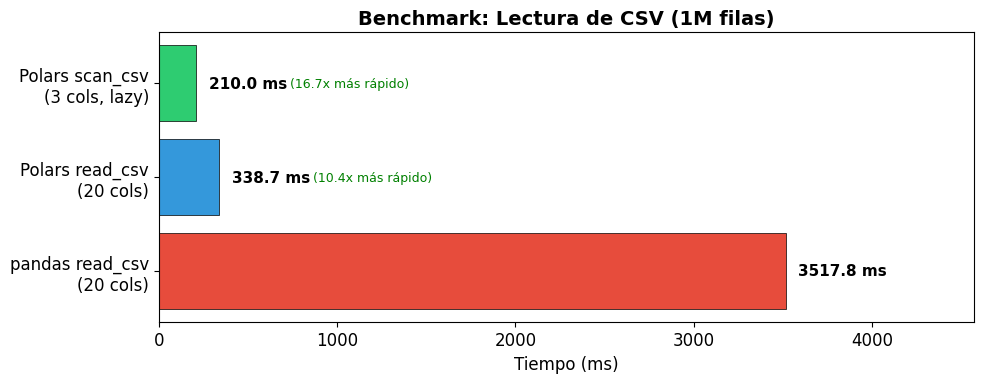

In [8]:
# --- Gráfica de resultados ---
plot_benchmark(
    names=["pandas read_csv\n(20 cols)", "Polars read_csv\n(20 cols)", "Polars scan_csv\n(3 cols, lazy)"],
    times=[t_pd_csv, t_pl_csv, t_pl_lazy],
    title="Benchmark: Lectura de CSV (1M filas)",
    filename="bench_lectura.png"
)

### Explicación de resultados

**¿Por qué Polars es más rápido que pandas para lectura?**

1. **Multi-threading:** Polars divide el archivo en chunks y los parsea en paralelo usando todos los cores de tu CPU. pandas usa un solo hilo.
2. **Implementación en Rust:** El parser de CSV de Polars está escrito en Rust, un lenguaje compilado. pandas usa una mezcla de C y Python.
3. **Memoria columnar:** Polars almacena datos en formato columnar (Apache Arrow), que es más eficiente para operaciones analíticas.

**¿Por qué scan_csv con 3 columnas es aún más rápido?**

Esto es **projection pushdown** en acción. Cuando Polars ve que solo necesitas 3 columnas, modifica el plan de lectura para:
- Saltar las 17 columnas que no necesitas
- No asignar memoria para esas columnas
- No parsear los valores de esas columnas

En datos reales con decenas o cientos de columnas, esta optimización puede ser **10-50x más rápida** que leer todo.

---
## §3: Benchmark — Filtrado

El filtrado es una de las operaciones más comunes: "dame solo las filas donde X cumple Y". Comparemos:

1. **pandas** — máscara booleana clásica: `df[df["col"] > valor]`
2. **Polars eager** — `df.filter(pl.col("col") > valor)`
3. **Polars lazy** — `lf.filter(pl.col("col") > valor).collect()`

### 🤔 Predicción

- El filtrado es una operación simple (comparación numérica). ¿Será la diferencia tan grande como en lectura?
- ¿Habrá diferencia entre Polars eager y lazy para una operación tan simple?

In [9]:
# --- Benchmark de filtrado ---
print("Benchmark: Filtrado numérico")
print(f"Operación: filas donde measurement > 50 (aprox. 50% de {N:,} filas)")
print()

# Verificar cuántas filas pasan el filtro
n_pass = (df_pl["measurement"] > 50).sum()
print(f"Filas que pasan el filtro: {n_pass:,} ({n_pass/N*100:.1f}%)")
print()

# 1. pandas — máscara booleana
t_pd_filter = benchmark(
    lambda: df_pd[df_pd["measurement"] > 50],
    name="pandas boolean mask"
)

# 2. Polars eager — filter con expresión
t_pl_filter = benchmark(
    lambda: df_pl.filter(pl.col("measurement") > 50),
    name="Polars eager filter"
)

# 3. Polars lazy — filter con expresión
# Creamos el LazyFrame una sola vez fuera del benchmark
lf = df_pl.lazy()
t_pl_lazy_filter = benchmark(
    lambda: lf.filter(pl.col("measurement") > 50).collect(),
    name="Polars lazy filter"
)

Benchmark: Filtrado numérico
Operación: filas donde measurement > 50 (aprox. 50% de 1,000,000 filas)

Filas que pasan el filtro: 499,151 (49.9%)



  pandas boolean mask: 151.6 ms  (min=122.1, max=293.2)
  Polars eager filter: 23.2 ms  (min=19.0, max=24.0)


  Polars lazy filter: 21.3 ms  (min=18.6, max=21.9)


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_filtrado.png


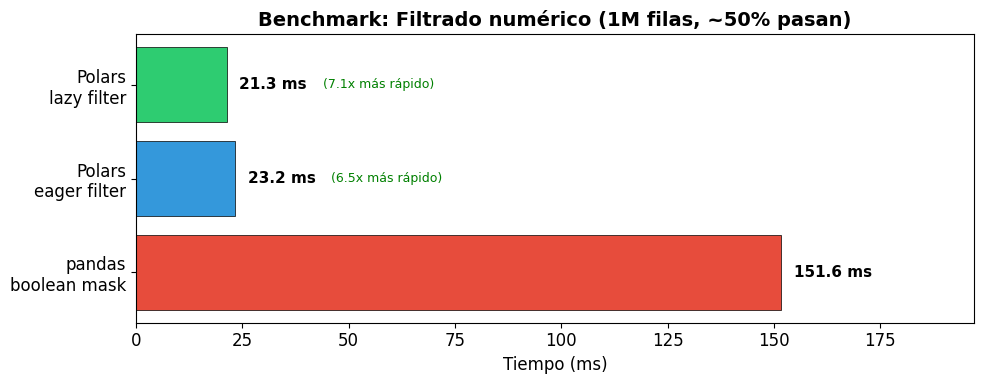

In [10]:
# --- Gráfica ---
plot_benchmark(
    names=["pandas\nboolean mask", "Polars\neager filter", "Polars\nlazy filter"],
    times=[t_pd_filter, t_pl_filter, t_pl_lazy_filter],
    title="Benchmark: Filtrado numérico (1M filas, ~50% pasan)",
    filename="bench_filtrado.png"
)

### Explicación

El filtrado es una operación relativamente simple: recorrer un array numérico y comparar cada valor con un umbral. Aun así, Polars suele ser más rápido porque:

1. **SIMD (Single Instruction, Multiple Data):** Polars (vía Rust/Arrow) usa instrucciones del procesador que comparan **múltiples valores al mismo tiempo** (8 floats de 64 bits en una sola instrucción con AVX-512).
2. **Sin copias innecesarias:** pandas muchas veces crea copias intermedias del array booleano y del resultado. Polars minimiza las copias.
3. **Multi-threading:** Incluso para filtrado, Polars puede dividir el trabajo entre hilos.

---
## §4: Benchmark — GroupBy + Aggregation

El groupby es el corazón del análisis de datos: "agrupa por categoría y calcula estadísticas". Comparemos con múltiples agregaciones simultáneas.

### 🤔 Predicción

- GroupBy con 100 grupos sobre 1M filas — ¿cuánto más rápido será Polars?
- Polars ejecuta **todas las agregaciones en paralelo** (sum, mean, count, max al mismo tiempo). ¿Hará diferencia?

In [11]:
# --- Benchmark de GroupBy ---
print("Benchmark: GroupBy + Agregación")
print(f"Operación: agrupar por 'cat_med' (100 grupos), calcular sum, mean, count, max")
print()

# 1. pandas groupby
t_pd_gb = benchmark(
    lambda: df_pd.groupby("cat_med").agg(
        price_sum=("price", "sum"),
        price_mean=("price", "mean"),
        count_total=("count", "count"),
        score_max=("score", "max")
    ),
    name="pandas groupby"
)

# 2. Polars eager groupby
t_pl_gb = benchmark(
    lambda: df_pl.group_by("cat_med").agg(
        pl.col("price").sum().alias("price_sum"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("count").count().alias("count_total"),
        pl.col("score").max().alias("score_max"),
    ),
    name="Polars eager group_by"
)

# 3. Polars lazy groupby
t_pl_lazy_gb = benchmark(
    lambda: lf.group_by("cat_med").agg(
        pl.col("price").sum().alias("price_sum"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("count").count().alias("count_total"),
        pl.col("score").max().alias("score_max"),
    ).collect(),
    name="Polars lazy group_by"
)

Benchmark: GroupBy + Agregación
Operación: agrupar por 'cat_med' (100 grupos), calcular sum, mean, count, max



  pandas groupby: 102.3 ms  (min=86.1, max=131.4)


  Polars eager group_by: 27.0 ms  (min=24.4, max=29.5)


  Polars lazy group_by: 27.3 ms  (min=26.3, max=30.5)


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_groupby.png


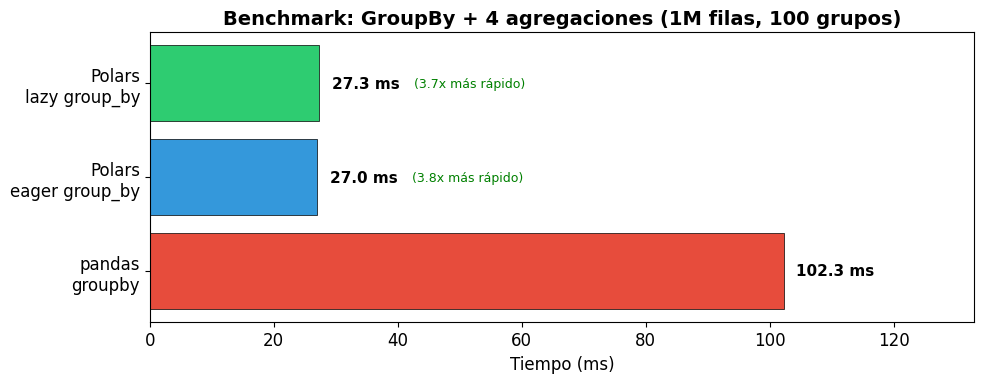

In [12]:
# --- Gráfica ---
plot_benchmark(
    names=["pandas\ngroupby", "Polars\neager group_by", "Polars\nlazy group_by"],
    times=[t_pd_gb, t_pl_gb, t_pl_lazy_gb],
    title="Benchmark: GroupBy + 4 agregaciones (1M filas, 100 grupos)",
    filename="bench_groupby.png"
)

### Explicación

Polars es particularmente rápido en GroupBy porque:

1. **Paralelismo de expresiones:** Las 4 agregaciones (sum, mean, count, max) se ejecutan **al mismo tiempo** en hilos separados. pandas las ejecuta secuencialmente.
2. **Hash table optimizada:** Polars usa una implementación de hash table en Rust altamente optimizada para agrupar.
3. **Sin overhead de Python:** Todo el cómputo ocurre en Rust. pandas tiene que ir y venir entre C y Python para cada operación.

> **Referencia:** La sección sobre expresiones paralelas en `02_arquitectura.md` explica cómo Polars paraleliza automáticamente las agregaciones dentro de un group_by.

---
## §5: Benchmark — Join

Los joins son fundamentales para combinar tablas. Vamos a hacer un join de la tabla principal (1M filas) con una tabla de lookup (1K filas) — un patrón muy común en data warehousing.

### 🤔 Predicción

- Join de 1M × 1K: es una operación de lookup, no un producto cartesiano. ¿Será rápido para ambas bibliotecas?
- ¿Hará diferencia el modo lazy vs eager para un join tan simple?

In [13]:
# --- Crear tabla de lookup ---
# Simulamos una tabla de referencia con 1000 categorías y su metadata
lookup_data = {
    "cat_high": [f"item_{i:04d}" for i in range(1000)],
    "category_name": [f"Nombre de categoría {i}" for i in range(1000)],
    "region": np.random.choice(["Norte", "Sur", "Este", "Oeste", "Centro"], size=1000),
    "priority": np.random.randint(1, 6, size=1000),
}

lookup_pd = pd.DataFrame(lookup_data)
lookup_pl = pl.DataFrame(lookup_data)

print(f"Tabla principal: {df_pl.shape[0]:,} filas × {df_pl.shape[1]} columnas")
print(f"Tabla de lookup: {lookup_pl.shape[0]:,} filas × {lookup_pl.shape[1]} columnas")
print(f"Join key: 'cat_high' (1000 valores únicos)")

Tabla principal: 1,000,000 filas × 20 columnas
Tabla de lookup: 1,000 filas × 4 columnas
Join key: 'cat_high' (1000 valores únicos)


In [14]:
# --- Benchmark de Join ---
print("Benchmark: Join (1M × 1K)")
print()

# 1. pandas merge
t_pd_join = benchmark(
    lambda: df_pd.merge(lookup_pd, on="cat_high", how="left"),
    name="pandas merge"
)

# 2. Polars eager join
t_pl_join = benchmark(
    lambda: df_pl.join(lookup_pl, on="cat_high", how="left"),
    name="Polars eager join"
)

# 3. Polars lazy join
lookup_lf = lookup_pl.lazy()
t_pl_lazy_join = benchmark(
    lambda: lf.join(lookup_lf, on="cat_high", how="left").collect(),
    name="Polars lazy join"
)

Benchmark: Join (1M × 1K)



  pandas merge: 446.7 ms  (min=358.2, max=474.1)


  Polars eager join: 30.7 ms  (min=27.8, max=33.6)


  Polars lazy join: 28.0 ms  (min=25.4, max=31.2)


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_join.png


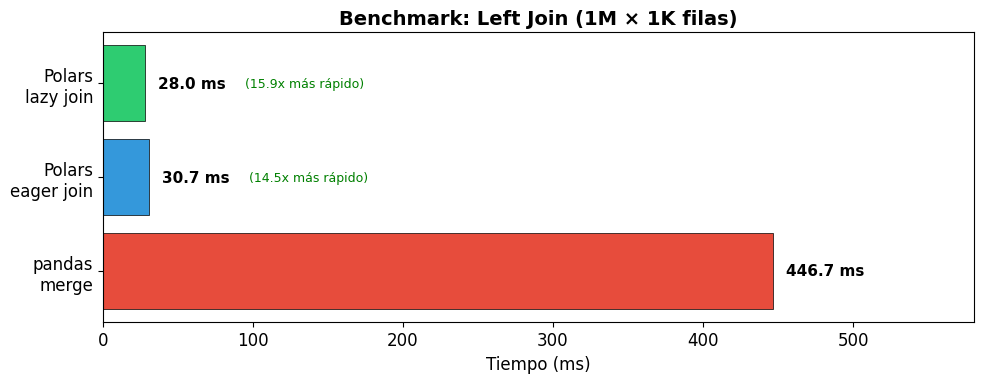

In [15]:
# --- Gráfica ---
plot_benchmark(
    names=["pandas\nmerge", "Polars\neager join", "Polars\nlazy join"],
    times=[t_pd_join, t_pl_join, t_pl_lazy_join],
    title="Benchmark: Left Join (1M × 1K filas)",
    filename="bench_join.png"
)

### Explicación

Los joins en Polars son rápidos por las mismas razones de siempre (Rust, multi-threading, Arrow), pero además:

1. **Algoritmo de hash join optimizado:** Polars construye una hash table de la tabla más pequeña y busca en ella para cada fila de la tabla grande. Esto es O(N + M), no O(N × M).
2. **Sin reorganización de índice:** pandas a veces reordena o resetea el índice después de un merge, lo cual agrega overhead. Polars no tiene índices.
3. **Memoria:** Polars usa menos memoria durante el join porque no crea DataFrames intermedios innecesarios.

---
## §6: Benchmark — Operaciones de texto + Pipeline encadenado

### Parte A: Operaciones de texto

Las operaciones de texto (string) son notoriamente lentas en pandas porque cada string es un objeto de Python. Polars usa strings UTF-8 contiguos en memoria.

### 🤔 Predicción

- Las operaciones de texto suelen ser donde Polars gana por **mayor margen**. ¿Cuánto? ¿3x? ¿10x?

In [16]:
# --- Benchmark de texto ---
print("Benchmark: Operaciones de texto")
print(f"Operación: lowercase + strip + filtrar donde contiene 'activ'")
print()

# 1. pandas — operaciones de texto en cadena
def pandas_text():
    temp = df_pd.copy()
    temp["status_clean"] = temp["status"].str.lower().str.strip()
    return temp[temp["status_clean"].str.contains("activ")]

t_pd_text = benchmark(pandas_text, name="pandas str ops")

# 2. Polars eager
def polars_text_eager():
    return df_pl.with_columns(
        pl.col("status").str.to_lowercase().str.strip_chars().alias("status_clean")
    ).filter(
        pl.col("status_clean").str.contains("activ")
    )

t_pl_text = benchmark(polars_text_eager, name="Polars eager str ops")

# 3. Polars lazy
def polars_text_lazy():
    return (
        lf.with_columns(
            pl.col("status").str.to_lowercase().str.strip_chars().alias("status_clean")
        )
        .filter(pl.col("status_clean").str.contains("activ"))
        .collect()
    )

t_pl_lazy_text = benchmark(polars_text_lazy, name="Polars lazy str ops")

Benchmark: Operaciones de texto
Operación: lowercase + strip + filtrar donde contiene 'activ'



  pandas str ops: 1320.1 ms  (min=1167.0, max=1988.6)


  Polars eager str ops: 222.9 ms  (min=203.2, max=355.1)


  Polars lazy str ops: 203.6 ms  (min=194.7, max=230.0)


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_texto.png


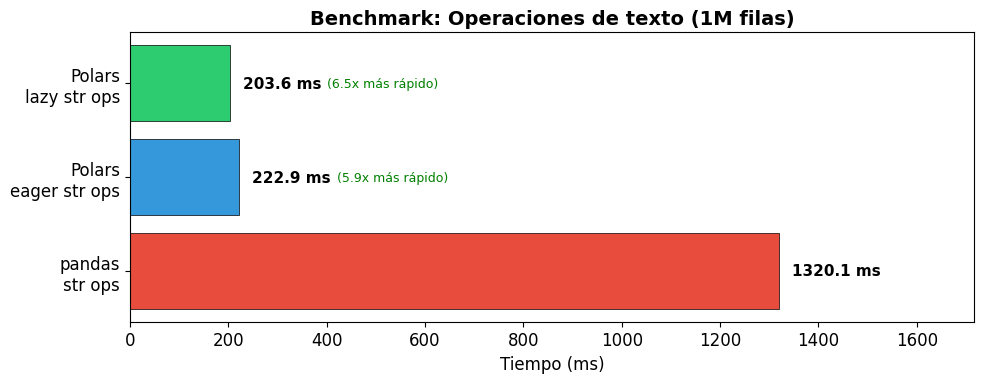

In [17]:
# --- Gráfica de texto ---
plot_benchmark(
    names=["pandas\nstr ops", "Polars\neager str ops", "Polars\nlazy str ops"],
    times=[t_pd_text, t_pl_text, t_pl_lazy_text],
    title="Benchmark: Operaciones de texto (1M filas)",
    filename="bench_texto.png"
)

### Parte B: Pipeline encadenado completo

Ahora la prueba más realista: un pipeline completo que combina múltiples operaciones. Esto simula lo que harías en un proyecto real:

1. **Leer** CSV (solo columnas necesarias)
2. **Filtrar** por condición numérica
3. **Limpiar** texto (lowercase, strip)
4. **Agrupar** por categoría
5. **Ordenar** resultado

En el modo lazy de Polars, **todas estas operaciones se optimizan juntas** antes de ejecutarse.

In [18]:
# --- Benchmark de Pipeline ---
print("Benchmark: Pipeline completo (read → filter → text → groupby → sort)")
print()

# 1. pandas — pipeline encadenado
def pandas_pipeline():
    # Leer CSV
    temp = pd.read_csv(csv_path, usecols=["price", "cat_low", "status", "measurement"])
    # Filtrar
    temp = temp[temp["measurement"] > 40]
    # Limpiar texto
    temp["status"] = temp["status"].str.lower().str.strip()
    # Agrupar
    result = temp.groupby("cat_low").agg(
        avg_price=("price", "mean"),
        count=("price", "count")
    )
    # Ordenar
    return result.sort_values("avg_price", ascending=False)

t_pd_pipe = benchmark(pandas_pipeline, name="pandas pipeline")

# 2. Polars lazy — todo en una cadena
def polars_pipeline():
    return (
        pl.scan_csv(csv_path)
        .select(["price", "cat_low", "status", "measurement"])  # Projection pushdown
        .filter(pl.col("measurement") > 40)                      # Predicate pushdown
        .with_columns(
            pl.col("status").str.to_lowercase().str.strip_chars()
        )
        .group_by("cat_low")
        .agg(
            pl.col("price").mean().alias("avg_price"),
            pl.col("price").count().alias("count"),
        )
        .sort("avg_price", descending=True)
        .collect()
    )

t_pl_pipe = benchmark(polars_pipeline, name="Polars lazy pipeline")

Benchmark: Pipeline completo (read → filter → text → groupby → sort)



  pandas pipeline: 2566.8 ms  (min=2425.2, max=3384.0)


  Polars lazy pipeline: 228.3 ms  (min=194.7, max=266.1)


### Plan de ejecución del pipeline lazy

Veamos cómo Polars optimiza internamente todo el pipeline:

In [19]:
# Mostrar el plan de ejecución del pipeline completo
plan_pipeline = (
    pl.scan_csv(csv_path)
    .select(["price", "cat_low", "status", "measurement"])
    .filter(pl.col("measurement") > 40)
    .with_columns(
        pl.col("status").str.to_lowercase().str.strip_chars()
    )
    .group_by("cat_low")
    .agg(
        pl.col("price").mean().alias("avg_price"),
        pl.col("price").count().alias("count"),
    )
    .sort("avg_price", descending=True)
    .explain()
)

print("Plan de ejecución del pipeline completo:")
print(plan_pipeline)
print()
print("Optimizaciones aplicadas:")
print("1. PROJECTION PUSHDOWN: Solo se leen 4 de 20 columnas del CSV")
print("2. PREDICATE PUSHDOWN: El filtro se aplica lo antes posible")
print("3. Las operaciones se fusionan en un plan ejecutable eficiente")

Plan de ejecución del pipeline completo:
SORT BY [col("avg_price")]
  AGGREGATE
    [col("price").mean().alias("avg_price"), col("price").count().alias("count")] BY [col("cat_low")]
    FROM
    simple π 3/3 ["price", "cat_low", ... 1 other column]
      Csv SCAN [/tmp/polars_bench_ta4x9drp/benchmark_data.csv]
      PROJECT 3/20 COLUMNS
      SELECTION: [(col("measurement")) > (40.0)]

Optimizaciones aplicadas:
1. PROJECTION PUSHDOWN: Solo se leen 4 de 20 columnas del CSV
2. PREDICATE PUSHDOWN: El filtro se aplica lo antes posible
3. Las operaciones se fusionan en un plan ejecutable eficiente


  Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_pipeline.png


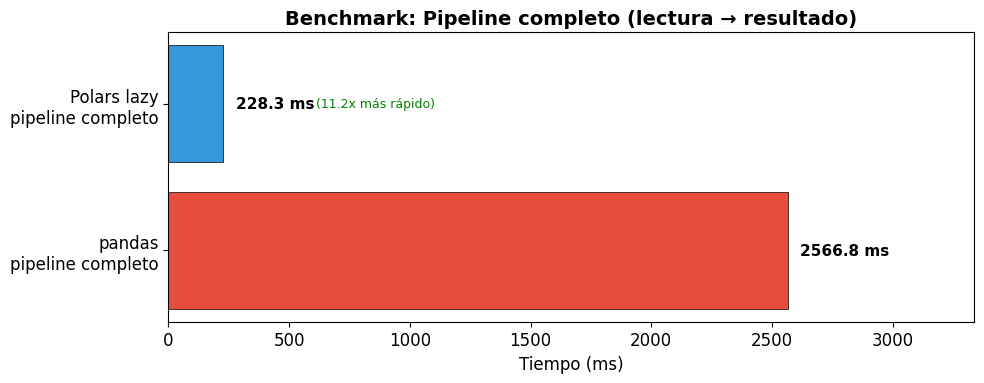

In [20]:
# --- Gráfica de pipeline ---
plot_benchmark(
    names=["pandas\npipeline completo", "Polars lazy\npipeline completo"],
    times=[t_pd_pipe, t_pl_pipe],
    title="Benchmark: Pipeline completo (lectura → resultado)",
    filename="bench_pipeline.png"
)

### Gráfica resumen: todos los benchmarks

Finalmente, juntemos todos los resultados en un solo gráfico para tener una visión global:

Gráfica guardada en: /home/uumami/itam/fdd_p26/clase/17_polars/images/bench_resumen.png


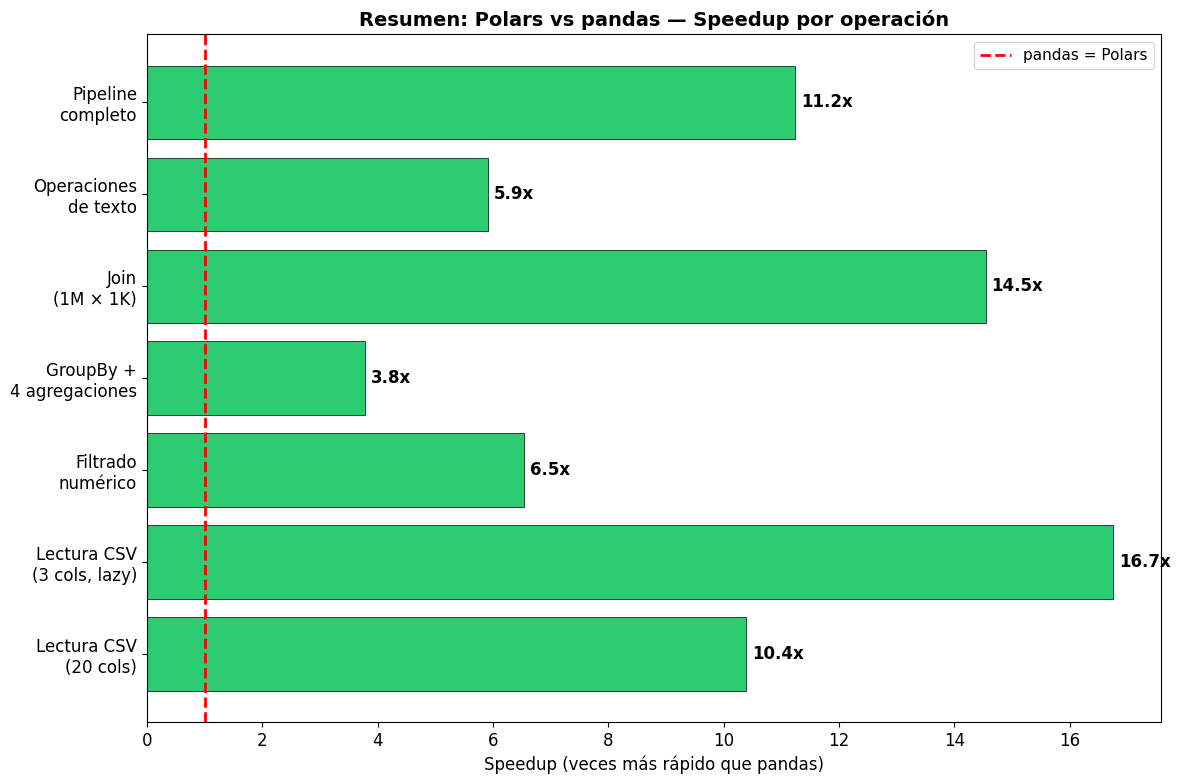

In [21]:
# --- Gráfica resumen con speedups ---
benchmarks = {
    "Lectura CSV\n(20 cols)": (t_pd_csv, t_pl_csv),
    "Lectura CSV\n(3 cols, lazy)": (t_pd_csv, t_pl_lazy),
    "Filtrado\nnumérico": (t_pd_filter, t_pl_filter),
    "GroupBy +\n4 agregaciones": (t_pd_gb, t_pl_gb),
    "Join\n(1M × 1K)": (t_pd_join, t_pl_join),
    "Operaciones\nde texto": (t_pd_text, t_pl_text),
    "Pipeline\ncompleto": (t_pd_pipe, t_pl_pipe),
}

fig, ax = plt.subplots(figsize=(12, 8))

names_list = list(benchmarks.keys())
speedups = [benchmarks[k][0] / benchmarks[k][1] for k in names_list]

colors_speedup = ['#2ecc71' if s > 2 else '#f1c40f' if s > 1 else '#e74c3c' for s in speedups]

bars = ax.barh(names_list, speedups, color=colors_speedup, edgecolor='black', linewidth=0.5)

# Línea de referencia en 1x (pandas = Polars)
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='pandas = Polars')

# Etiquetas
for bar, s in zip(bars, speedups):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{s:.1f}x', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Speedup (veces más rápido que pandas)', fontsize=12)
ax.set_title('Resumen: Polars vs pandas — Speedup por operación', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
save_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'images', 'bench_resumen.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Gráfica guardada en: {save_path}")
plt.show()

### Conclusiones de los benchmarks

1. **Polars es consistentemente más rápido que pandas** en todas las operaciones medidas.
2. **Las mayores ganancias** se ven en operaciones de texto y pipelines completos, donde el overhead de Python en pandas es más notorio.
3. **El modo lazy** brilla cuando puedes aplicar projection pushdown (leer menos columnas) y predicate pushdown (filtrar antes).
4. **Para operaciones simples** (filtrado numérico, join), la diferencia es menor pero Polars sigue ganando gracias a SIMD y multi-threading.

> **Moraleja:** Si tus datos caben en memoria y trabajas con menos de ~10M filas, Polars es la mejor opción. Para datos más grandes, considera PySpark o DuckDB (que también usan Arrow).

---
---

# PARTE 2: Series de Tiempo en Polars

Las series de tiempo son uno de los tipos de datos más comunes en la práctica:
- **Finanzas:** precios de acciones, transacciones, tipos de cambio
- **IoT/Sensores:** temperatura, humedad, presión, cada N segundos
- **Web:** logs de servidores, clics de usuarios, métricas de API
- **Ciencia:** mediciones experimentales, datos climáticos, señales biomédicas

Polars tiene **soporte nativo y altamente optimizado** para operaciones temporales. En esta sección exploraremos desde los tipos básicos hasta operaciones avanzadas como rolling windows y group_by_dynamic.

> **Referencia:** Los tipos temporales de Polars se mencionan brevemente en `01_historia_y_diseno.md`. Aquí los exploramos en profundidad.

---
## §7.1: Tipos temporales en Polars

Polars tiene 4 tipos temporales principales. Es crucial entender cada uno:

| Tipo | Representa | Ejemplo | Representación interna |
|------|-----------|---------|----------------------|
| `Date` | Una fecha (sin hora) | 2026-03-15 | Días desde 1970-01-01 (epoch) |
| `Datetime` | Fecha + hora con precisión configurable | 2026-03-15 14:30:00 | Microsegundos desde epoch (por defecto) |
| `Duration` | Diferencia entre dos instantes | 3 días, 2 horas | Microsegundos (por defecto) |
| `Time` | Hora del día (sin fecha) | 14:30:00 | Nanosegundos desde medianoche |

### Representación interna

Esto es importante para entender el rendimiento:
- `Date` internamente es un **entero de 32 bits** (número de días desde 1970-01-01). Esto significa que las operaciones con fechas son tan rápidas como operaciones con enteros.
- `Datetime` internamente es un **entero de 64 bits** (microsegundos desde epoch por defecto). También admite nanosegundos y milisegundos.
- `Duration` es la diferencia: si restas dos `Datetime`, obtienes un `Duration`.

Comparación con pandas:
- pandas usa `datetime64[ns]` de NumPy (siempre nanosegundos, 64 bits)
- Polars es más flexible: puedes elegir la precisión (ms, us, ns)
- Polars maneja zonas horarias de forma más explícita

In [22]:
# --- Crear columnas de cada tipo temporal ---
import datetime as dt_module

df_temporal = pl.DataFrame({
    "id": [1, 2, 3, 4, 5],
    # Date: solo fecha, sin hora
    "fecha": [
        dt_module.date(2026, 1, 15),
        dt_module.date(2026, 2, 20),
        dt_module.date(2026, 3, 10),
        dt_module.date(2026, 4, 5),
        dt_module.date(2026, 5, 25),
    ],
    # Datetime: fecha + hora
    "timestamp": [
        dt_module.datetime(2026, 1, 15, 8, 30, 0),
        dt_module.datetime(2026, 2, 20, 14, 15, 30),
        dt_module.datetime(2026, 3, 10, 22, 0, 0),
        dt_module.datetime(2026, 4, 5, 6, 45, 15),
        dt_module.datetime(2026, 5, 25, 18, 0, 0),
    ],
    # Time: solo hora del día
    "hora": [
        dt_module.time(8, 30),
        dt_module.time(14, 15),
        dt_module.time(22, 0),
        dt_module.time(6, 45),
        dt_module.time(18, 0),
    ],
})

print("DataFrame con tipos temporales:")
print(df_temporal)
print()
print("Tipos de cada columna:")
print(df_temporal.dtypes)

DataFrame con tipos temporales:
shape: (5, 4)
┌─────┬────────────┬─────────────────────┬──────────┐
│ id  ┆ fecha      ┆ timestamp           ┆ hora     │
│ --- ┆ ---        ┆ ---                 ┆ ---      │
│ i64 ┆ date       ┆ datetime[μs]        ┆ time     │
╞═════╪════════════╪═════════════════════╪══════════╡
│ 1   ┆ 2026-01-15 ┆ 2026-01-15 08:30:00 ┆ 08:30:00 │
│ 2   ┆ 2026-02-20 ┆ 2026-02-20 14:15:30 ┆ 14:15:00 │
│ 3   ┆ 2026-03-10 ┆ 2026-03-10 22:00:00 ┆ 22:00:00 │
│ 4   ┆ 2026-04-05 ┆ 2026-04-05 06:45:15 ┆ 06:45:00 │
│ 5   ┆ 2026-05-25 ┆ 2026-05-25 18:00:00 ┆ 18:00:00 │
└─────┴────────────┴─────────────────────┴──────────┘

Tipos de cada columna:
[Int64, Date, Datetime(time_unit='us', time_zone=None), Time]


### Parsear strings a fechas

En datos reales, las fechas casi siempre llegan como **strings** (texto). Polars puede convertirlas usando `str.to_date()` o `str.to_datetime()` con un formato especificado.

Los formatos usan la notación de strftime:
- `%Y` = año de 4 dígitos (2026)
- `%m` = mes de 2 dígitos (03)
- `%d` = día de 2 dígitos (15)
- `%H` = hora 24h (14)
- `%M` = minutos (30)
- `%S` = segundos (00)

In [23]:
# --- Parsear strings a fechas ---
df_strings = pl.DataFrame({
    "fecha_iso": ["2026-01-15", "2026-02-20", "2026-03-10"],
    "fecha_slash": ["15/01/2026", "20/02/2026", "10/03/2026"],
    "timestamp_str": ["2026-01-15 08:30:00", "2026-02-20 14:15:30", "2026-03-10 22:00:00"],
})

# Convertir strings a tipos temporales
df_parsed = df_strings.with_columns(
    # ISO format: YYYY-MM-DD → Date
    pl.col("fecha_iso").str.to_date("%Y-%m-%d").alias("fecha_date"),
    
    # Formato DD/MM/YYYY → Date
    pl.col("fecha_slash").str.to_date("%d/%m/%Y").alias("fecha_slash_date"),
    
    # String con hora → Datetime
    pl.col("timestamp_str").str.to_datetime("%Y-%m-%d %H:%M:%S").alias("timestamp_dt"),
)

print("Strings originales y columnas parseadas:")
print(df_parsed)
print()
print("Tipos:")
for col in df_parsed.columns:
    print(f"  {col}: {df_parsed[col].dtype}")

Strings originales y columnas parseadas:
shape: (3, 6)
┌────────────┬─────────────┬───────────────┬────────────┬──────────────────┬───────────────────────┐
│ fecha_iso  ┆ fecha_slash ┆ timestamp_str ┆ fecha_date ┆ fecha_slash_date ┆ timestamp_dt          │
│ ---        ┆ ---         ┆ ---           ┆ ---        ┆ ---              ┆ ---                   │
│ str        ┆ str         ┆ str           ┆ date       ┆ date             ┆ datetime[μs]          │
╞════════════╪═════════════╪═══════════════╪════════════╪══════════════════╪═══════════════════════╡
│ 2026-01-15 ┆ 15/01/2026  ┆ 2026-01-15    ┆ 2026-01-15 ┆ 2026-01-15       ┆ 2026-01-15 08:30:00   │
│            ┆             ┆ 08:30:00      ┆            ┆                  ┆                       │
│ 2026-02-20 ┆ 20/02/2026  ┆ 2026-02-20    ┆ 2026-02-20 ┆ 2026-02-20       ┆ 2026-02-20 14:15:30   │
│            ┆             ┆ 14:15:30      ┆            ┆                  ┆                       │
│ 2026-03-10 ┆ 10/03/2026  ┆ 2026-03

### Zonas horarias

Polars maneja zonas horarias de forma explícita. Un `Datetime` puede ser:
- **Naive** (sin zona horaria): no sabes si es hora de México, Madrid o Tokio
- **Aware** (con zona horaria): sabes exactamente qué instante del tiempo universal representa

Operaciones clave:
- `dt.replace_time_zone("zona")`: **asigna** una zona horaria (no convierte, solo etiqueta)
- `dt.convert_time_zone("zona")`: **convierte** de una zona a otra (ajusta la hora)

In [24]:
# --- Zonas horarias ---
df_tz = pl.DataFrame({
    "evento": ["Clase ITAM", "Reunión Madrid", "Deploy Tokio"],
    "hora_local": [
        dt_module.datetime(2026, 3, 15, 10, 0),   # 10:00 AM
        dt_module.datetime(2026, 3, 15, 17, 0),   # 5:00 PM
        dt_module.datetime(2026, 3, 15, 3, 0),    # 3:00 AM
    ],
})

# Asignar zona horaria (estas horas SON en la zona indicada)
df_tz = df_tz.with_columns(
    pl.col("hora_local").dt.replace_time_zone("America/Mexico_City").alias("hora_cdmx"),
)

# Convertir a otras zonas horarias
df_tz = df_tz.with_columns(
    pl.col("hora_cdmx").dt.convert_time_zone("Europe/Madrid").alias("hora_madrid"),
    pl.col("hora_cdmx").dt.convert_time_zone("Asia/Tokyo").alias("hora_tokyo"),
    pl.col("hora_cdmx").dt.convert_time_zone("UTC").alias("hora_utc"),
)

print("Horas en diferentes zonas horarias:")
print(df_tz.select("evento", "hora_cdmx", "hora_madrid", "hora_tokyo", "hora_utc"))

Horas en diferentes zonas horarias:
shape: (3, 5)
┌────────────────┬───────────────────────────┬────────────────┬──────────────┬─────────────────────┐
│ evento         ┆ hora_cdmx                 ┆ hora_madrid    ┆ hora_tokyo   ┆ hora_utc            │
│ ---            ┆ ---                       ┆ ---            ┆ ---          ┆ ---                 │
│ str            ┆ datetime[μs,              ┆ datetime[μs,   ┆ datetime[μs, ┆ datetime[μs, UTC]   │
│                ┆ America/Mexico_City]      ┆ Europe/Madrid] ┆ Asia/Tokyo]  ┆                     │
╞════════════════╪═══════════════════════════╪════════════════╪══════════════╪═════════════════════╡
│ Clase ITAM     ┆ 2026-03-15 10:00:00 CST   ┆ 2026-03-15     ┆ 2026-03-16   ┆ 2026-03-15 16:00:00 │
│                ┆                           ┆ 17:00:00 CET   ┆ 01:00:00 JST ┆ UTC                 │
│ Reunión Madrid ┆ 2026-03-15 17:00:00 CST   ┆ 2026-03-16     ┆ 2026-03-16   ┆ 2026-03-15 23:00:00 │
│                ┆                       

### Extraer componentes de una fecha/hora

Una vez que tienes una columna temporal, puedes extraer componentes individuales. Esto es muy útil para crear features en modelos de ML:

In [25]:
# --- Extraer componentes ---
df_components = pl.DataFrame({
    "timestamp": pl.date_range(
        dt_module.datetime(2026, 1, 1),
        dt_module.datetime(2026, 12, 31),
        interval="1mo",  # Un dato por mes
        eager=True
    ),
})

df_components = df_components.with_columns(
    pl.col("timestamp").dt.year().alias("año"),
    pl.col("timestamp").dt.month().alias("mes"),
    pl.col("timestamp").dt.day().alias("dia"),
    pl.col("timestamp").dt.weekday().alias("dia_semana"),  # 1=lunes, 7=domingo
    pl.col("timestamp").dt.ordinal_day().alias("dia_del_año"),
    pl.col("timestamp").dt.quarter().alias("trimestre"),
    # ¿Es fin de semana? (sábado=6, domingo=7)
    (pl.col("timestamp").dt.weekday() >= 6).alias("es_fin_de_semana"),
)

print("Componentes extraídos de timestamps:")
print(df_components)

Componentes extraídos de timestamps:
shape: (12, 8)
┌────────────┬──────┬─────┬─────┬────────────┬─────────────┬───────────┬──────────────────┐
│ timestamp  ┆ año  ┆ mes ┆ dia ┆ dia_semana ┆ dia_del_año ┆ trimestre ┆ es_fin_de_semana │
│ ---        ┆ ---  ┆ --- ┆ --- ┆ ---        ┆ ---         ┆ ---       ┆ ---              │
│ date       ┆ i32  ┆ i8  ┆ i8  ┆ i8         ┆ i16         ┆ i8        ┆ bool             │
╞════════════╪══════╪═════╪═════╪════════════╪═════════════╪═══════════╪══════════════════╡
│ 2026-01-01 ┆ 2026 ┆ 1   ┆ 1   ┆ 4          ┆ 1           ┆ 1         ┆ false            │
│ 2026-02-01 ┆ 2026 ┆ 2   ┆ 1   ┆ 7          ┆ 32          ┆ 1         ┆ true             │
│ 2026-03-01 ┆ 2026 ┆ 3   ┆ 1   ┆ 7          ┆ 60          ┆ 1         ┆ true             │
│ 2026-04-01 ┆ 2026 ┆ 4   ┆ 1   ┆ 3          ┆ 91          ┆ 2         ┆ false            │
│ 2026-05-01 ┆ 2026 ┆ 5   ┆ 1   ┆ 5          ┆ 121         ┆ 2         ┆ false            │
│ …          ┆ …    ┆ …   ┆ 

---
## §7.2: Generar datos de series de tiempo realistas

Para las siguientes secciones necesitamos datos que simulen un escenario real: **sensores que reportan lecturas cada ~5 minutos**. Los datos tendrán las imperfecciones típicas del mundo real:

- **Irregularidad temporal:** Los sensores no reportan exactamente cada 5 minutos — hay jitter (variación) de ±2 minutos.
- **Datos faltantes:** Algunos timestamps no existen (el sensor se desconectó).
- **Duplicados:** Algunos timestamps aparecen dos veces (el sensor reenvió un dato).
- **Outliers:** Algunos valores son anómalamente altos o bajos (error de medición).
- **Múltiples sensores:** 5 sensores con patrones ligeramente diferentes.

In [26]:
# --- Generar datos de sensores ---
np.random.seed(42)

n_sensors = 5
sensor_ids = [f"sensor_{i:02d}" for i in range(n_sensors)]

# Periodo: 30 días de datos, ~5 minutos entre lecturas
start = dt_module.datetime(2026, 1, 1, 0, 0, 0)
end = dt_module.datetime(2026, 1, 31, 23, 59, 59)

# Generar timestamps base: cada 5 minutos
timestamps_base = pl.datetime_range(start, end, interval="5m", eager=True)
n_per_sensor = len(timestamps_base)

print(f"Timestamps base por sensor: {n_per_sensor:,}")
print(f"Total estimado: {n_per_sensor * n_sensors:,} filas")

all_records = []

for sensor_id in sensor_ids:
    # Jitter: agregar ±2 minutos de variación aleatoria
    jitter_seconds = np.random.randint(-120, 120, size=n_per_sensor)
    
    # Crear timestamps con jitter
    ts_series = timestamps_base + pl.Series(
        [dt_module.timedelta(seconds=int(s)) for s in jitter_seconds]
    )
    
    # Valor base: patrón sinusoidal (simula ciclo diario) + ruido
    hours = np.arange(n_per_sensor) * 5 / 60  # horas transcurridas
    base_value = 50 + 20 * np.sin(2 * np.pi * hours / 24)  # Ciclo de 24 horas
    noise = np.random.normal(0, 3, size=n_per_sensor)        # Ruido gaussiano
    
    # Cada sensor tiene un offset diferente
    sensor_offset = hash(sensor_id) % 10 - 5
    values = base_value + noise + sensor_offset
    
    # Calidad del dato
    quality = np.random.choice(
        ["buena", "regular", "mala"],
        size=n_per_sensor,
        p=[0.85, 0.10, 0.05]  # 85% buena, 10% regular, 5% mala
    )
    
    # Crear DataFrame parcial para este sensor
    sensor_df = pl.DataFrame({
        "timestamp": ts_series,
        "sensor_id": [sensor_id] * n_per_sensor,
        "value": values,
        "quality": quality,
    })
    
    all_records.append(sensor_df)

# Concatenar todos los sensores
df_sensors = pl.concat(all_records)

# --- Introducir imperfecciones ---

# 1. Eliminar ~2% de filas (simular datos faltantes)
n_total = df_sensors.height
mask_keep = np.random.random(n_total) > 0.02  # Mantener 98%
df_sensors = df_sensors.filter(pl.Series(mask_keep))

# 2. Duplicar ~0.5% de filas (simular reenvíos)
n_dups = int(n_total * 0.005)
dup_indices = np.random.choice(df_sensors.height, size=n_dups, replace=False)
duplicates = df_sensors[dup_indices.tolist()]
df_sensors = pl.concat([df_sensors, duplicates])

# 3. Introducir outliers en ~1% de los valores
n_outliers = int(df_sensors.height * 0.01)
outlier_mask = np.zeros(df_sensors.height, dtype=bool)
outlier_indices = np.random.choice(df_sensors.height, size=n_outliers, replace=False)
outlier_mask[outlier_indices] = True
outlier_values = np.where(
    outlier_mask,
    np.random.choice([-50, 150, 200, -100], size=df_sensors.height),  # Valores extremos
    0
)
df_sensors = df_sensors.with_columns(
    (pl.col("value") + pl.Series("outlier_add", outlier_values)).alias("value")
)

# Ordenar por timestamp y sensor_id
df_sensors = df_sensors.sort(["sensor_id", "timestamp"])

print(f"\nDataFrame de sensores final:")
print(f"  Filas: {df_sensors.height:,}")
print(f"  Columnas: {df_sensors.width}")
print(f"  Sensores: {df_sensors['sensor_id'].n_unique()}")
print(f"  Rango temporal: {df_sensors['timestamp'].min()} → {df_sensors['timestamp'].max()}")
print()
print(df_sensors.head(10))

Timestamps base por sensor: 8,928
Total estimado: 44,640 filas

DataFrame de sensores final:
  Filas: 43,975
  Columnas: 4
  Sensores: 5
  Rango temporal: 2025-12-31 23:58:15 → 2026-01-31 23:56:33

shape: (10, 4)
┌─────────────────────┬───────────┬────────────┬─────────┐
│ timestamp           ┆ sensor_id ┆ value      ┆ quality │
│ ---                 ┆ ---       ┆ ---        ┆ ---     │
│ datetime[μs]        ┆ str       ┆ f64        ┆ str     │
╞═════════════════════╪═══════════╪════════════╪═════════╡
│ 2025-12-31 23:59:42 ┆ sensor_00 ┆ 46.00976   ┆ buena   │
│ 2026-01-01 00:05:59 ┆ sensor_00 ┆ 46.174346  ┆ buena   │
│ 2026-01-01 00:09:32 ┆ sensor_00 ┆ 48.945885  ┆ buena   │
│ 2026-01-01 00:13:14 ┆ sensor_00 ┆ 45.449692  ┆ buena   │
│ 2026-01-01 00:19:46 ┆ sensor_00 ┆ 47.509416  ┆ buena   │
│ 2026-01-01 00:24:11 ┆ sensor_00 ┆ 42.027712  ┆ buena   │
│ 2026-01-01 00:31:08 ┆ sensor_00 ┆ 46.364573  ┆ buena   │
│ 2026-01-01 00:33:20 ┆ sensor_00 ┆ 200.609677 ┆ mala    │
│ 2026-01-01 00:39:4

---
## §7.3: Rolling windows — Promedios móviles sobre ventanas temporales

### ¿Qué es una rolling window (ventana móvil)?

Imagina que tienes un termómetro que mide la temperatura cada 5 minutos. En lugar de ver cada medición individual (que tiene ruido), quieres ver el **promedio de la última hora**. Esto es exactamente lo que hace una rolling window.

```
Datos:     ●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●
           08:00  08:05  08:10  08:15  08:20  08:25  08:30  08:35  08:40  08:45  08:50  08:55

Ventana de 1 hora centrada en 08:30:
           [                    ●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●]
           08:00  08:05  08:10  08:15  08:20  08:25  08:30  08:35  08:40  08:45  08:50  08:55
           └──────────────────── 1 hora ────────────────────┘
           
Ventana de 1 hora centrada en 08:45:
                                       [●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●  ●]
                                       08:00  08:05  08:10  08:15  ...  08:55
                                       └────────────────── 1 hora ──────────┘
```

La ventana se **desliza** a lo largo del tiempo, calculando la estadística (mean, std, etc.) para cada posición.

### Diferencia clave con pandas

- En **pandas**, `rolling(12)` significa "las últimas 12 **filas**", sin importar el tiempo entre ellas.
- En **Polars**, `rolling_mean(by="timestamp", window_size="1h")` significa "los últimos **60 minutos**", sin importar cuántas filas hay.

Esto es crucial cuando los datos son **irregulares** (timestamps no equiespaciados). Con pandas, 12 filas podrían cubrir 1 hora o 3 horas dependiendo de los gaps. Con Polars, siempre es exactamente 1 hora.

### Complejidad

Rolling windows en Polars son **O(n)** cuando los datos están ordenados por tiempo (que es nuestro caso). No necesita escanear toda la ventana para cada fila — mantiene un acumulador que actualiza incrementalmente.

In [27]:
# --- Rolling windows ---
# Trabajamos con un solo sensor primero para entender el concepto
df_s00 = df_sensors.filter(pl.col("sensor_id") == "sensor_00")

print(f"Datos del sensor_00: {df_s00.height:,} filas")
print(f"Rango: {df_s00['timestamp'].min()} → {df_s00['timestamp'].max()}")
print()

# Rolling mean de 1 hora
df_rolling = df_s00.with_columns(
    # Promedio móvil de 1 hora
    pl.col("value").rolling_mean_by(
        by="timestamp",        # Columna temporal que define la ventana
        window_size="1h",      # Ventana de 1 hora
    ).alias("rolling_mean_1h"),
    
    # Desviación estándar móvil de 1 hora
    pl.col("value").rolling_std_by(
        by="timestamp",
        window_size="1h",
    ).alias("rolling_std_1h"),
    
    # Mínimo móvil de 1 hora
    pl.col("value").rolling_min_by(
        by="timestamp",
        window_size="1h",
    ).alias("rolling_min_1h"),
    
    # Máximo móvil de 1 hora
    pl.col("value").rolling_max_by(
        by="timestamp",
        window_size="1h",
    ).alias("rolling_max_1h"),
)

print("Primeras 20 filas con rolling windows:")
print(df_rolling.select(
    "timestamp", "value", "rolling_mean_1h", "rolling_std_1h", "rolling_min_1h", "rolling_max_1h"
).head(20))

Datos del sensor_00: 8,780 filas
Rango: 2025-12-31 23:59:42 → 2026-01-31 23:56:33

Primeras 20 filas con rolling windows:
shape: (20, 6)
┌──────────────┬───────────┬─────────────────┬────────────────┬────────────────┬────────────────┐
│ timestamp    ┆ value     ┆ rolling_mean_1h ┆ rolling_std_1h ┆ rolling_min_1h ┆ rolling_max_1h │
│ ---          ┆ ---       ┆ ---             ┆ ---            ┆ ---            ┆ ---            │
│ datetime[μs] ┆ f64       ┆ f64             ┆ f64            ┆ f64            ┆ f64            │
╞══════════════╪═══════════╪═════════════════╪════════════════╪════════════════╪════════════════╡
│ 2025-12-31   ┆ 46.00976  ┆ 46.00976        ┆ null           ┆ 46.00976       ┆ 46.00976       │
│ 23:59:42     ┆           ┆                 ┆                ┆                ┆                │
│ 2026-01-01   ┆ 46.174346 ┆ 46.092053       ┆ 0.11638        ┆ 46.00976       ┆ 46.174346      │
│ 00:05:59     ┆           ┆                 ┆                ┆                

### Efecto de timestamps irregulares

Veamos qué pasa cuando hay gaps en los datos. Con una ventana temporal, el tamaño de la ventana en **filas** varía, pero el tamaño en **tiempo** es siempre el mismo:

In [28]:
# --- Mostrar efecto de irregularidad ---
# Tomemos una sección con gap
sample = df_rolling.filter(
    (pl.col("timestamp") >= dt_module.datetime(2026, 1, 5, 10, 0)) &
    (pl.col("timestamp") <= dt_module.datetime(2026, 1, 5, 14, 0))
).select("timestamp", "value", "rolling_mean_1h")

print("Sección con posibles irregularidades (observe los intervalos entre timestamps):")
print(sample.head(30))
print()
print("Note: los timestamps no son exactamente cada 5 minutos debido al jitter.")
print("La ventana rolling SIEMPRE cubre exactamente 1 hora de tiempo,")
print("sin importar cuántas filas haya en ese periodo.")

Sección con posibles irregularidades (observe los intervalos entre timestamps):
shape: (30, 3)
┌─────────────────────┬───────────┬─────────────────┐
│ timestamp           ┆ value     ┆ rolling_mean_1h │
│ ---                 ┆ ---       ┆ ---             │
│ datetime[μs]        ┆ f64       ┆ f64             │
╞═════════════════════╪═══════════╪═════════════════╡
│ 2026-01-05 10:05:58 ┆ 54.632798 ┆ 58.424488       │
│ 2026-01-05 10:10:52 ┆ 56.461557 ┆ 58.146355       │
│ 2026-01-05 10:13:43 ┆ 52.282768 ┆ 57.69531        │
│ 2026-01-05 10:20:12 ┆ 59.108512 ┆ 58.052253       │
│ 2026-01-05 10:24:09 ┆ 50.270895 ┆ 57.401638       │
│ …                   ┆ …         ┆ …               │
│ 2026-01-05 12:11:54 ┆ 42.413503 ┆ 45.650358       │
│ 2026-01-05 12:13:02 ┆ 42.064511 ┆ 45.374523       │
│ 2026-01-05 12:20:40 ┆ 42.123115 ┆ 44.986636       │
│ 2026-01-05 12:25:13 ┆ 40.576728 ┆ 44.029054       │
│ 2026-01-05 12:30:57 ┆ 43.196543 ┆ 43.634888       │
└─────────────────────┴───────────┴──────

### Rolling por grupo (usando .over)

En la práctica queremos calcular rolling windows **por sensor** — no queremos que la ventana de un sensor se contamine con datos de otro. Usamos `.over("sensor_id")` para esto.

> **Referencia:** El concepto de `.over()` (window functions) se explica en `02_arquitectura.md`.

In [29]:
# --- Rolling por grupo ---
# IMPORTANTE: Los datos deben estar ordenados por timestamp DENTRO de cada grupo
df_sensors_sorted = df_sensors.sort(["sensor_id", "timestamp"])

# Calcular rolling mean de 1 hora POR SENSOR
df_with_rolling = df_sensors_sorted.with_columns(
    pl.col("value").rolling_mean_by(
        by="timestamp",
        window_size="1h",
    ).over("sensor_id").alias("rolling_mean_1h"),
)

# Verificar: cada sensor tiene sus propios promedios móviles
print("Rolling mean por sensor (primeras filas de cada sensor):")
for sid in ["sensor_00", "sensor_01", "sensor_02"]:
    sample = df_with_rolling.filter(pl.col("sensor_id") == sid).head(5)
    print(f"\n{sid}:")
    print(sample.select("timestamp", "sensor_id", "value", "rolling_mean_1h"))

Rolling mean por sensor (primeras filas de cada sensor):

sensor_00:
shape: (5, 4)
┌─────────────────────┬───────────┬───────────┬─────────────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ rolling_mean_1h │
│ ---                 ┆ ---       ┆ ---       ┆ ---             │
│ datetime[μs]        ┆ str       ┆ f64       ┆ f64             │
╞═════════════════════╪═══════════╪═══════════╪═════════════════╡
│ 2025-12-31 23:59:42 ┆ sensor_00 ┆ 46.00976  ┆ 46.00976        │
│ 2026-01-01 00:05:59 ┆ sensor_00 ┆ 46.174346 ┆ 46.092053       │
│ 2026-01-01 00:09:32 ┆ sensor_00 ┆ 48.945885 ┆ 47.04333        │
│ 2026-01-01 00:13:14 ┆ sensor_00 ┆ 45.449692 ┆ 46.644921       │
│ 2026-01-01 00:19:46 ┆ sensor_00 ┆ 47.509416 ┆ 46.81782        │
└─────────────────────┴───────────┴───────────┴─────────────────┘

sensor_01:
shape: (5, 4)
┌─────────────────────┬───────────┬───────────┬─────────────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ rolling_mean_1h │
│ ---                 ┆ ---      

---
## §7.4: group_by_dynamic — Ventanas temporales fijas

### ¿Qué es group_by_dynamic?

Mientras que `rolling` calcula una estadística para **cada fila** usando una ventana que se desliza, `group_by_dynamic` divide el tiempo en **buckets (cubetas) fijas** y agrega todas las filas que caen en cada bucket.

```
Datos:     ●  ● ●   ●  ●●  ●   ● ●  ●   ●  ●  ●●  ●   ●  ●
Tiempo:    08:00          09:00          10:00          11:00

group_by_dynamic(every="1h"):

Bucket 1: [08:00 - 09:00)  →  ●  ● ●   ●  ●●  ●   →  mean=47.3, count=7
Bucket 2: [09:00 - 10:00)  →  ● ●  ●   ●  ●  ●●   →  mean=52.1, count=7
Bucket 3: [10:00 - 11:00)  →  ●   ●  ●               →  mean=49.8, count=3
```

### Diferencia con group_by normal

- `group_by("categoria")` agrupa por **valores** de una columna categórica.
- `group_by_dynamic("timestamp", every="1h")` agrupa por **intervalos de tiempo** fijos.

### Parámetros clave

| Parámetro | Significado | Ejemplo |
|-----------|-------------|---------|
| `every` | Cada cuánto se crea un nuevo bucket | `"1h"`, `"15m"`, `"1d"` |
| `period` | Tamaño de cada bucket (por defecto = every) | `"2h"` (buckets que se solapan) |
| `offset` | Desplazar el inicio de los buckets | `"-30m"` |
| `closed` | Qué extremo del intervalo se incluye | `"left"` (default), `"right"`, `"both"`, `"none"` |
| `label` | Qué extremo del intervalo se usa como etiqueta | `"left"` (default), `"right"`, `"datapoint"` |
| `group_by` | Columna adicional para agrupar (como sensor_id) | `group_by="sensor_id"` |

In [30]:
# --- group_by_dynamic: ventanas de 1 hora ---
# Datos de un solo sensor para claridad
df_s00 = df_sensors.filter(pl.col("sensor_id") == "sensor_00").sort("timestamp")

# Agregar lecturas en ventanas de 1 hora
hourly = df_s00.group_by_dynamic(
    "timestamp",     # Columna temporal
    every="1h",      # Crear un bucket cada hora
).agg(
    pl.col("value").mean().alias("valor_medio"),
    pl.col("value").std().alias("valor_std"),
    pl.col("value").min().alias("valor_min"),
    pl.col("value").max().alias("valor_max"),
    pl.col("value").count().alias("n_lecturas"),
)

print("Agregación horaria del sensor_00:")
print(hourly.head(15))
print(f"\nTotal de buckets horarios: {hourly.height}")

Agregación horaria del sensor_00:
shape: (15, 6)
┌─────────────────────┬─────────────┬───────────┬───────────┬────────────┬────────────┐
│ timestamp           ┆ valor_medio ┆ valor_std ┆ valor_min ┆ valor_max  ┆ n_lecturas │
│ ---                 ┆ ---         ┆ ---       ┆ ---       ┆ ---        ┆ ---        │
│ datetime[μs]        ┆ f64         ┆ f64       ┆ f64       ┆ f64        ┆ u32        │
╞═════════════════════╪═════════════╪═══════════╪═══════════╪════════════╪════════════╡
│ 2025-12-31 23:00:00 ┆ 46.00976    ┆ null      ┆ 46.00976  ┆ 46.00976   ┆ 1          │
│ 2026-01-01 00:00:00 ┆ 59.66318    ┆ 44.439705 ┆ 42.027712 ┆ 200.609677 ┆ 12         │
│ 2026-01-01 01:00:00 ┆ 53.594436   ┆ 3.147755  ┆ 46.854993 ┆ 57.258228  ┆ 11         │
│ 2026-01-01 02:00:00 ┆ 56.69118    ┆ 2.650729  ┆ 52.863776 ┆ 61.601013  ┆ 11         │
│ 2026-01-01 03:00:00 ┆ 62.690521   ┆ 3.436752  ┆ 57.044475 ┆ 67.110891  ┆ 11         │
│ …                   ┆ …           ┆ …         ┆ …         ┆ …        

### Ventanas de 15 minutos

Podemos usar intervalos más finos para mayor resolución temporal:

In [31]:
# --- Ventanas de 15 minutos ---
quarterly = df_s00.group_by_dynamic(
    "timestamp",
    every="15m",     # Bucket cada 15 minutos
).agg(
    pl.col("value").mean().alias("valor_medio"),
    pl.col("value").count().alias("n_lecturas"),
)

print("Agregación cada 15 minutos:")
print(quarterly.head(20))
print(f"\nTotal de buckets de 15 min: {quarterly.height}")

Agregación cada 15 minutos:
shape: (20, 3)
┌─────────────────────┬─────────────┬────────────┐
│ timestamp           ┆ valor_medio ┆ n_lecturas │
│ ---                 ┆ ---         ┆ ---        │
│ datetime[μs]        ┆ f64         ┆ u32        │
╞═════════════════════╪═════════════╪════════════╡
│ 2025-12-31 23:45:00 ┆ 46.00976    ┆ 1          │
│ 2026-01-01 00:00:00 ┆ 46.856641   ┆ 3          │
│ 2026-01-01 00:15:00 ┆ 44.768564   ┆ 2          │
│ 2026-01-01 00:30:00 ┆ 97.143243   ┆ 3          │
│ 2026-01-01 00:45:00 ┆ 48.605346   ┆ 4          │
│ …                   ┆ …           ┆ …          │
│ 2026-01-01 03:30:00 ┆ 60.007678   ┆ 3          │
│ 2026-01-01 03:45:00 ┆ 63.681694   ┆ 3          │
│ 2026-01-01 04:00:00 ┆ 60.710884   ┆ 3          │
│ 2026-01-01 04:15:00 ┆ 60.960829   ┆ 2          │
│ 2026-01-01 04:30:00 ┆ 64.421195   ┆ 4          │
└─────────────────────┴─────────────┴────────────┘

Total de buckets de 15 min: 2977


### El parámetro `closed`: ¿qué extremo incluir?

El parámetro `closed` controla si los límites del intervalo están incluidos:

```
Intervalo [09:00, 10:00):  closed="left"   → incluye 09:00, NO incluye 10:00
Intervalo (09:00, 10:00]:  closed="right"  → NO incluye 09:00, incluye 10:00
Intervalo [09:00, 10:00]:  closed="both"   → incluye ambos extremos
Intervalo (09:00, 10:00):  closed="none"   → NO incluye ningún extremo
```

El default es `closed="left"`, que es el más común y el que tiene mejor rendimiento.

In [32]:
# --- Comparar opciones de closed ---
# Tomemos 2 horas de datos para ver las diferencias
sample_2h = df_s00.filter(
    (pl.col("timestamp") >= dt_module.datetime(2026, 1, 2, 8, 0)) &
    (pl.col("timestamp") <= dt_module.datetime(2026, 1, 2, 10, 0))
)

print(f"Datos en ventana de ejemplo: {sample_2h.height} filas")
print()

for closed_opt in ["left", "right", "both", "none"]:
    result = sample_2h.group_by_dynamic(
        "timestamp",
        every="1h",
        closed=closed_opt,
    ).agg(
        pl.col("value").count().alias("n_lecturas"),
    )
    print(f"closed='{closed_opt}':")
    print(result)
    print()

Datos en ventana de ejemplo: 23 filas

closed='left':
shape: (2, 2)
┌─────────────────────┬────────────┐
│ timestamp           ┆ n_lecturas │
│ ---                 ┆ ---        │
│ datetime[μs]        ┆ u32        │
╞═════════════════════╪════════════╡
│ 2026-01-02 08:00:00 ┆ 11         │
│ 2026-01-02 09:00:00 ┆ 12         │
└─────────────────────┴────────────┘



closed='right':
shape: (2, 2)
┌─────────────────────┬────────────┐
│ timestamp           ┆ n_lecturas │
│ ---                 ┆ ---        │
│ datetime[μs]        ┆ u32        │
╞═════════════════════╪════════════╡
│ 2026-01-02 08:00:00 ┆ 11         │
│ 2026-01-02 09:00:00 ┆ 12         │
└─────────────────────┴────────────┘

closed='both':
shape: (2, 2)
┌─────────────────────┬────────────┐
│ timestamp           ┆ n_lecturas │
│ ---                 ┆ ---        │
│ datetime[μs]        ┆ u32        │
╞═════════════════════╪════════════╡
│ 2026-01-02 08:00:00 ┆ 11         │
│ 2026-01-02 09:00:00 ┆ 12         │
└─────────────────────┴────────────┘

closed='none':
shape: (2, 2)
┌─────────────────────┬────────────┐
│ timestamp           ┆ n_lecturas │
│ ---                 ┆ ---        │
│ datetime[μs]        ┆ u32        │
╞═════════════════════╪════════════╡
│ 2026-01-02 08:00:00 ┆ 11         │
│ 2026-01-02 09:00:00 ┆ 12         │
└─────────────────────┴────────────┘



### group_by_dynamic con agrupación por sensor

El caso más útil: dividir en ventanas temporales **por sensor**:

In [33]:
# --- group_by_dynamic por sensor ---
# Esto es el equivalente a: "para cada sensor, divide las lecturas en ventanas de 6 horas"
hourly_by_sensor = df_sensors.sort("timestamp").group_by_dynamic(
    "timestamp",
    every="6h",           # Buckets de 6 horas
    group_by="sensor_id", # Agrupar también por sensor
).agg(
    pl.col("value").mean().alias("valor_medio"),
    pl.col("value").std().alias("valor_std"),
    pl.col("value").count().alias("n_lecturas"),
)

print("Agregación cada 6 horas por sensor:")
print(hourly_by_sensor.head(20))
print(f"\nTotal de buckets: {hourly_by_sensor.height}")
print(f"Buckets por sensor: ~{hourly_by_sensor.height // n_sensors}")

Agregación cada 6 horas por sensor:
shape: (20, 5)
┌───────────┬─────────────────────┬─────────────┬───────────┬────────────┐
│ sensor_id ┆ timestamp           ┆ valor_medio ┆ valor_std ┆ n_lecturas │
│ ---       ┆ ---                 ┆ ---         ┆ ---       ┆ ---        │
│ str       ┆ datetime[μs]        ┆ f64         ┆ f64       ┆ u32        │
╞═══════════╪═════════════════════╪═════════════╪═══════════╪════════════╡
│ sensor_00 ┆ 2025-12-31 18:00:00 ┆ 46.00976    ┆ null      ┆ 1          │
│ sensor_00 ┆ 2026-01-01 00:00:00 ┆ 60.167597   ┆ 18.810626 ┆ 67         │
│ sensor_00 ┆ 2026-01-01 06:00:00 ┆ 59.752576   ┆ 19.372528 ┆ 73         │
│ sensor_00 ┆ 2026-01-01 12:00:00 ┆ 32.52862    ┆ 6.905011  ┆ 70         │
│ sensor_00 ┆ 2026-01-01 18:00:00 ┆ 31.563853   ┆ 6.916106  ┆ 70         │
│ …         ┆ …                   ┆ …           ┆ …         ┆ …          │
│ sensor_00 ┆ 2026-01-04 12:00:00 ┆ 34.228105   ┆ 19.784284 ┆ 70         │
│ sensor_00 ┆ 2026-01-04 18:00:00 ┆ 32.121275   ┆

---
## §7.5: Lag/Lead — Agregar observaciones pasadas como features

### ¿Para qué sirve lag/lead?

En machine learning con series de tiempo, una técnica fundamental es usar **observaciones pasadas como features** (variables predictoras). Por ejemplo:

- Para predecir la temperatura en t, usamos las temperaturas en t-1, t-2, t-3 como features.
- Para detectar anomalías, comparamos el valor actual con el promedio de las últimas N observaciones.

Operaciones clave:
- **`.shift(n)`** — Lag: desplaza la serie n posiciones hacia abajo (trae valores pasados).
- **`.shift(-n)`** — Lead: desplaza n posiciones hacia arriba (trae valores futuros, solo para análisis, ¡no para predicción en producción!).
- **`.diff(n)`** — Diferencia entre el valor actual y el de n posiciones atrás.
- **`.pct_change(n)`** — Cambio porcentual respecto a n posiciones atrás.

### CRÍTICO: `.over("sensor_id")`

Cuando tienes múltiples sensores, **DEBES** usar `.over("sensor_id")` para que el lag se calcule **dentro de cada grupo**. Sin esto, el lag de la primera lectura del sensor_01 tomaría el valor de la última lectura del sensor_00, lo cual no tiene sentido.

In [34]:
# --- Lag/Lead features ---
# Usar datos ordenados por sensor y timestamp
df_features = df_sensors.sort(["sensor_id", "timestamp"])

# Agregar features de lag POR SENSOR
df_features = df_features.with_columns(
    # Lag: valores pasados (t-1, t-2, t-3)
    pl.col("value").shift(1).over("sensor_id").alias("value_t-1"),   # Valor hace 1 lectura
    pl.col("value").shift(2).over("sensor_id").alias("value_t-2"),   # Valor hace 2 lecturas
    pl.col("value").shift(3).over("sensor_id").alias("value_t-3"),   # Valor hace 3 lecturas
    
    # Diff: cambio respecto a la lectura anterior
    pl.col("value").diff(1).over("sensor_id").alias("cambio"),       # value[t] - value[t-1]
    
    # Pct change: cambio porcentual
    pl.col("value").pct_change(1).over("sensor_id").alias("cambio_pct"),  # (v[t]-v[t-1])/v[t-1]
)

print("DataFrame con features de lag (sensor_00, primeras 10 filas):")
print(
    df_features
    .filter(pl.col("sensor_id") == "sensor_00")
    .select("timestamp", "value", "value_t-1", "value_t-2", "value_t-3", "cambio", "cambio_pct")
    .head(10)
)

DataFrame con features de lag (sensor_00, primeras 10 filas):
shape: (10, 7)
┌──────────────┬────────────┬────────────┬────────────┬───────────┬─────────────┬────────────┐
│ timestamp    ┆ value      ┆ value_t-1  ┆ value_t-2  ┆ value_t-3 ┆ cambio      ┆ cambio_pct │
│ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---         ┆ ---        │
│ datetime[μs] ┆ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64         ┆ f64        │
╞══════════════╪════════════╪════════════╪════════════╪═══════════╪═════════════╪════════════╡
│ 2025-12-31   ┆ 46.00976   ┆ null       ┆ null       ┆ null      ┆ null        ┆ null       │
│ 23:59:42     ┆            ┆            ┆            ┆           ┆             ┆            │
│ 2026-01-01   ┆ 46.174346  ┆ 46.00976   ┆ null       ┆ null      ┆ 0.164585    ┆ 0.003577   │
│ 00:05:59     ┆            ┆            ┆            ┆           ┆             ┆            │
│ 2026-01-01   ┆ 48.945885  ┆ 46.174346  ┆ 46.00976   ┆ null      ┆ 

### Verificar que `.over()` funciona correctamente

Veamos la transición entre sensores para confirmar que los lags **no se cruzan** entre grupos:

In [35]:
# --- Verificar que los lags no se cruzan entre sensores ---
# Últimas filas del sensor_00 y primeras del sensor_01
transition = df_features.filter(
    (pl.col("sensor_id") == "sensor_00") | (pl.col("sensor_id") == "sensor_01")
)

# Mostrar las últimas 3 filas del sensor_00 y las primeras 3 del sensor_01
last_s00 = transition.filter(pl.col("sensor_id") == "sensor_00").tail(3)
first_s01 = transition.filter(pl.col("sensor_id") == "sensor_01").head(3)

print("Últimas 3 filas del sensor_00:")
print(last_s00.select("timestamp", "sensor_id", "value", "value_t-1"))
print()
print("Primeras 3 filas del sensor_01:")
print(first_s01.select("timestamp", "sensor_id", "value", "value_t-1"))
print()
print("Observa: value_t-1 del sensor_01 es null al inicio,")
print("NO toma el último valor del sensor_00. ¡Esto es correcto!")

Últimas 3 filas del sensor_00:
shape: (3, 4)
┌─────────────────────┬───────────┬───────────┬───────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ value_t-1 │
│ ---                 ┆ ---       ┆ ---       ┆ ---       │
│ datetime[μs]        ┆ str       ┆ f64       ┆ f64       │
╞═════════════════════╪═══════════╪═══════════╪═══════════╡
│ 2026-01-31 23:43:39 ┆ sensor_00 ┆ 40.350222 ┆ 40.810698 │
│ 2026-01-31 23:49:09 ┆ sensor_00 ┆ 46.350475 ┆ 40.350222 │
│ 2026-01-31 23:56:33 ┆ sensor_00 ┆ 41.613097 ┆ 46.350475 │
└─────────────────────┴───────────┴───────────┴───────────┘

Primeras 3 filas del sensor_01:
shape: (3, 4)
┌─────────────────────┬───────────┬───────────┬───────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ value_t-1 │
│ ---                 ┆ ---       ┆ ---       ┆ ---       │
│ datetime[μs]        ┆ str       ┆ f64       ┆ f64       │
╞═════════════════════╪═══════════╪═══════════╪═══════════╡
│ 2025-12-31 23:59:23 ┆ sensor_01 ┆ 49.074536 ┆ null      │
│ 2026-0

### Uso en ML: preparar tabla de features

Así se vería la preparación de datos para un modelo de machine learning que predice el valor del sensor:

In [36]:
# --- Tabla completa de features para ML ---
df_ml = (
    df_sensors
    .sort(["sensor_id", "timestamp"])
    .with_columns(
        # Features temporales (extraer componentes del timestamp)
        pl.col("timestamp").dt.weekday().alias("dia_semana"),
        
        # Features de lag
        pl.col("value").shift(1).over("sensor_id").alias("lag_1"),
        pl.col("value").shift(2).over("sensor_id").alias("lag_2"),
        pl.col("value").shift(3).over("sensor_id").alias("lag_3"),
        
        # Features de cambio
        pl.col("value").diff(1).over("sensor_id").alias("diff_1"),
        pl.col("value").diff(2).over("sensor_id").alias("diff_2"),
        
        # Rolling features (promedio y std de las últimas 6 lecturas)
        pl.col("value").rolling_mean(window_size=6).over("sensor_id").alias("rolling_mean_6"),
        pl.col("value").rolling_std(window_size=6).over("sensor_id").alias("rolling_std_6"),
    )
    # Eliminar filas con nulls (las primeras de cada sensor no tienen lags)
    .drop_nulls(subset=["lag_3", "rolling_std_6"])
)

print(f"Tabla de features para ML: {df_ml.shape}")
print(f"Columnas: {df_ml.columns}")
print()
print("Primeras filas:")
print(df_ml.head(8))

Tabla de features para ML: (43950, 12)
Columnas: ['timestamp', 'sensor_id', 'value', 'quality', 'dia_semana', 'lag_1', 'lag_2', 'lag_3', 'diff_1', 'diff_2', 'rolling_mean_6', 'rolling_std_6']

Primeras filas:
shape: (8, 12)
┌────────────┬───────────┬───────────┬─────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ timestamp  ┆ sensor_id ┆ value     ┆ quality ┆ … ┆ diff_1    ┆ diff_2    ┆ rolling_m ┆ rolling_s │
│ ---        ┆ ---       ┆ ---       ┆ ---     ┆   ┆ ---       ┆ ---       ┆ ean_6     ┆ td_6      │
│ datetime[μ ┆ str       ┆ f64       ┆ str     ┆   ┆ f64       ┆ f64       ┆ ---       ┆ ---       │
│ s]         ┆           ┆           ┆         ┆   ┆           ┆           ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2026-01-01 ┆ sensor_00 ┆ 42.027712 ┆ buena   ┆ … ┆ -5.481705 ┆ -3.42198  ┆ 46.019468 ┆ 2.326659  │
│ 00:24:11   ┆           ┆           ┆         ┆   ┆           ┆     

---
## §7.6: Agregaciones temporales complejas

Aquí combinamos todo lo que hemos visto: rolling windows, group_by_dynamic, y el poder de las expresiones de Polars. La idea es mostrar que puedes construir pipelines temporales sofisticados **en una sola cadena lazy**.

### Ejemplo 1: Promedio móvil + diferencia con observación anterior

"Para cada sensor, calcula el promedio móvil de 1 hora, y la diferencia del valor actual con la observación anterior." 

In [37]:
# --- Ejemplo 1: Rolling + diff por sensor ---
result_1 = (
    df_sensors
    .sort(["sensor_id", "timestamp"])
    .with_columns(
        # Promedio móvil de 1 hora por sensor
        pl.col("value")
        .rolling_mean_by(by="timestamp", window_size="1h")
        .over("sensor_id")
        .alias("rolling_mean_1h"),
        
        # Diferencia con la observación anterior por sensor
        pl.col("value")
        .diff(1)
        .over("sensor_id")
        .alias("diff_prev"),
    )
    .with_columns(
        # Desviación del valor respecto al promedio móvil
        (pl.col("value") - pl.col("rolling_mean_1h")).alias("desviacion_de_media"),
    )
)

print("Ejemplo 1: Rolling mean + diff + desviación")
print(result_1.filter(pl.col("sensor_id") == "sensor_00").head(15).select(
    "timestamp", "sensor_id", "value", "rolling_mean_1h", "diff_prev", "desviacion_de_media"
))

Ejemplo 1: Rolling mean + diff + desviación
shape: (15, 6)
┌─────────────────────┬───────────┬───────────┬─────────────────┬───────────┬─────────────────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ rolling_mean_1h ┆ diff_prev ┆ desviacion_de_media │
│ ---                 ┆ ---       ┆ ---       ┆ ---             ┆ ---       ┆ ---                 │
│ datetime[μs]        ┆ str       ┆ f64       ┆ f64             ┆ f64       ┆ f64                 │
╞═════════════════════╪═══════════╪═══════════╪═════════════════╪═══════════╪═════════════════════╡
│ 2025-12-31 23:59:42 ┆ sensor_00 ┆ 46.00976  ┆ 46.00976        ┆ null      ┆ 0.0                 │
│ 2026-01-01 00:05:59 ┆ sensor_00 ┆ 46.174346 ┆ 46.092053       ┆ 0.164585  ┆ 0.082293            │
│ 2026-01-01 00:09:32 ┆ sensor_00 ┆ 48.945885 ┆ 47.04333        ┆ 2.771539  ┆ 1.902554            │
│ 2026-01-01 00:13:14 ┆ sensor_00 ┆ 45.449692 ┆ 46.644921       ┆ -3.496193 ┆ -1.195229           │
│ 2026-01-01 00:19:46 ┆ sensor_00 ┆ 47.50

### Ejemplo 2: Detección de outliers con ventanas temporales

"Para cada sensor en ventanas de 6 horas, calcula: media, desviación estándar, min, max, y número de outliers (valores que se desvían más de 2 desviaciones estándar de la media rolling)."

Este es un pipeline más complejo que combina `group_by_dynamic` con expresiones avanzadas:

In [38]:
# --- Ejemplo 2: Detección de outliers en ventanas de 6 horas ---
# Primero, calcular rolling stats para detectar outliers
df_with_stats = (
    df_sensors
    .sort(["sensor_id", "timestamp"])
    .with_columns(
        pl.col("value")
        .rolling_mean_by(by="timestamp", window_size="1h")
        .over("sensor_id")
        .alias("rolling_mean"),
        
        pl.col("value")
        .rolling_std_by(by="timestamp", window_size="1h")
        .over("sensor_id")
        .alias("rolling_std"),
    )
    .with_columns(
        # Marcar outliers: |valor - media_rolling| > 2 * std_rolling
        (
            (pl.col("value") - pl.col("rolling_mean")).abs() > 2 * pl.col("rolling_std")
        ).alias("es_outlier")
    )
)

# Ahora agregar en ventanas de 6 horas por sensor
outlier_summary = (
    df_with_stats
    .sort("timestamp")
    .group_by_dynamic(
        "timestamp",
        every="6h",
        group_by="sensor_id",
    )
    .agg(
        pl.col("value").mean().alias("media"),
        pl.col("value").std().alias("std"),
        pl.col("value").min().alias("minimo"),
        pl.col("value").max().alias("maximo"),
        pl.col("value").count().alias("n_lecturas"),
        pl.col("es_outlier").sum().alias("n_outliers"),
        # Porcentaje de outliers
        (pl.col("es_outlier").sum() / pl.col("es_outlier").count() * 100)
        .round(1)
        .alias("pct_outliers"),
    )
)

print("Resumen de outliers por ventana de 6 horas:")
print(outlier_summary.filter(pl.col("sensor_id") == "sensor_00").head(15))
print(f"\nVentanas con más del 5% de outliers:")
print(outlier_summary.filter(pl.col("pct_outliers") > 5).head(10))

Resumen de outliers por ventana de 6 horas:
shape: (15, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ sensor_id ┆ timestamp ┆ media     ┆ std       ┆ … ┆ maximo    ┆ n_lectura ┆ n_outlier ┆ pct_outl │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ s         ┆ s         ┆ iers     │
│ str       ┆ datetime[ ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ μs]       ┆           ┆           ┆   ┆           ┆ u32       ┆ u32       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ sensor_00 ┆ 2025-12-3 ┆ 46.00976  ┆ null      ┆ … ┆ 46.00976  ┆ 1         ┆ 0         ┆ NaN      │
│           ┆ 1         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ 18:00:00  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ sensor_00 ┆ 2026-01-0 ┆ 60.167

---
## §7.7: Resampling e interpolación

### El problema de los datos irregulares

Nuestros datos de sensores tienen timestamps **irregulares** (jitter de ±2 minutos). Muchos algoritmos de ML y estadísticos requieren datos **regulares** — exactamente cada 5 minutos, sin gaps.

**Resampling** es el proceso de convertir datos irregulares a regulares. Polars ofrece dos herramientas:
1. **`upsample`**: crea filas vacías en los timestamps faltantes.
2. **`interpolate`**: rellena los valores faltantes usando interpolación lineal.

Además, hay estrategias simples:
- **`forward_fill`**: propagar el último valor conocido hacia adelante.
- **`backward_fill`**: propagar el siguiente valor conocido hacia atrás.

### ¿Cuándo usar cada estrategia?

| Estrategia | Cuándo usarla | Ejemplo |
|-----------|--------------|---------|
| Interpolación lineal | Datos continuos que cambian gradualmente | Temperatura, presión |
| Forward fill | Datos que "se mantienen" hasta el siguiente cambio | Estado de un sistema, precio de cierre |
| Backward fill | Necesitas el "próximo valor conocido" | Programación de eventos |
| Valor constante (fill_null) | Sabes el valor correcto para los faltantes | 0 para conteos, -1 para flags |

In [39]:
# --- Resampling e interpolación ---
# Trabajar con un solo sensor para claridad
df_s00 = (
    df_sensors
    .filter(pl.col("sensor_id") == "sensor_00")
    .sort("timestamp")
    .select("timestamp", "value")
)

print(f"Datos originales del sensor_00: {df_s00.height:,} filas")
print(f"Rango: {df_s00['timestamp'].min()} → {df_s00['timestamp'].max()}")
print()

# Paso 1: upsample — crear filas en intervalos regulares de 5 minutos
df_resampled = df_s00.upsample("timestamp", every="5m")

print(f"Después de upsample (cada 5 min): {df_resampled.height:,} filas")
print(f"Filas con valor null: {df_resampled['value'].is_null().sum()}")
print()
print("Muestra con nulls (donde no había dato original):")
print(df_resampled.filter(pl.col("value").is_null()).head(10))

Datos originales del sensor_00: 8,780 filas
Rango: 2025-12-31 23:59:42 → 2026-01-31 23:56:33

Después de upsample (cada 5 min): 8,928 filas
Filas con valor null: 8894

Muestra con nulls (donde no había dato original):
shape: (10, 2)
┌─────────────────────┬───────┐
│ timestamp           ┆ value │
│ ---                 ┆ ---   │
│ datetime[μs]        ┆ f64   │
╞═════════════════════╪═══════╡
│ 2026-01-01 00:04:42 ┆ null  │
│ 2026-01-01 00:09:42 ┆ null  │
│ 2026-01-01 00:14:42 ┆ null  │
│ 2026-01-01 00:19:42 ┆ null  │
│ 2026-01-01 00:24:42 ┆ null  │
│ 2026-01-01 00:29:42 ┆ null  │
│ 2026-01-01 00:34:42 ┆ null  │
│ 2026-01-01 00:44:42 ┆ null  │
│ 2026-01-01 00:49:42 ┆ null  │
│ 2026-01-01 00:54:42 ┆ null  │
└─────────────────────┴───────┘


In [40]:
# --- Interpolación ---
# Método 1: Interpolación lineal
df_interp = df_resampled.with_columns(
    pl.col("value").interpolate().alias("value_interpolated"),
)

# Método 2: Forward fill (propagar último valor conocido)
df_ffill = df_resampled.with_columns(
    pl.col("value").forward_fill().alias("value_ffill"),
)

# Método 3: Backward fill
df_bfill = df_resampled.with_columns(
    pl.col("value").backward_fill().alias("value_bfill"),
)

# Mostrar una sección donde hay nulls para comparar las estrategias
# Encontrar el primer null y mostrar alrededor
null_mask = df_resampled["value"].is_null()
if null_mask.any():
    first_null_idx = null_mask.arg_true()[0]
    start_idx = max(0, first_null_idx - 3)
    end_idx = min(df_resampled.height, first_null_idx + 5)
    
    comparison = pl.DataFrame({
        "timestamp": df_resampled["timestamp"][start_idx:end_idx],
        "original": df_resampled["value"][start_idx:end_idx],
        "interpolado": df_interp["value_interpolated"][start_idx:end_idx],
        "forward_fill": df_ffill["value_ffill"][start_idx:end_idx],
        "backward_fill": df_bfill["value_bfill"][start_idx:end_idx],
    })
    
    print("Comparación de estrategias de relleno:")
    print(comparison)
    print()
    print("- 'original': null donde no había dato")
    print("- 'interpolado': promedio lineal entre vecinos")
    print("- 'forward_fill': repite el último valor conocido")
    print("- 'backward_fill': usa el próximo valor conocido")

Comparación de estrategias de relleno:
shape: (6, 5)
┌─────────────────────┬──────────┬─────────────┬──────────────┬───────────────┐
│ timestamp           ┆ original ┆ interpolado ┆ forward_fill ┆ backward_fill │
│ ---                 ┆ ---      ┆ ---         ┆ ---          ┆ ---           │
│ datetime[μs]        ┆ f64      ┆ f64         ┆ f64          ┆ f64           │
╞═════════════════════╪══════════╪═════════════╪══════════════╪═══════════════╡
│ 2025-12-31 23:59:42 ┆ 46.00976 ┆ 46.00976    ┆ 46.00976     ┆ 46.00976      │
│ 2026-01-01 00:04:42 ┆ null     ┆ 45.815475   ┆ 46.00976     ┆ 44.455478     │
│ 2026-01-01 00:09:42 ┆ null     ┆ 45.62119    ┆ 46.00976     ┆ 44.455478     │
│ 2026-01-01 00:14:42 ┆ null     ┆ 45.426904   ┆ 46.00976     ┆ 44.455478     │
│ 2026-01-01 00:19:42 ┆ null     ┆ 45.232619   ┆ 46.00976     ┆ 44.455478     │
│ 2026-01-01 00:24:42 ┆ null     ┆ 45.038334   ┆ 46.00976     ┆ 44.455478     │
└─────────────────────┴──────────┴─────────────┴──────────────┴────

### Pipeline completo: irregular → regular → interpolado

In [41]:
# --- Pipeline completo de resampling ---
df_regular = (
    df_sensors
    .filter(pl.col("sensor_id") == "sensor_00")
    .sort("timestamp")
    .select("timestamp", "value")
    # Paso 1: Crear intervalos regulares
    .upsample("timestamp", every="5m")
    # Paso 2: Interpolar valores faltantes
    .with_columns(
        pl.col("value").interpolate().alias("value"),
    )
)

print(f"Pipeline de resampling completo:")
print(f"  Filas originales: {df_s00.height:,}")
print(f"  Filas después de resample + interpolación: {df_regular.height:,}")
print(f"  Valores null restantes: {df_regular['value'].is_null().sum()}")
print()
print("Datos regulares (cada 5 minutos exactos):")
print(df_regular.head(15))

Pipeline de resampling completo:
  Filas originales: 8,780
  Filas después de resample + interpolación: 8,928
  Valores null restantes: 234

Datos regulares (cada 5 minutos exactos):
shape: (15, 2)
┌─────────────────────┬───────────┐
│ timestamp           ┆ value     │
│ ---                 ┆ ---       │
│ datetime[μs]        ┆ f64       │
╞═════════════════════╪═══════════╡
│ 2025-12-31 23:59:42 ┆ 46.00976  │
│ 2026-01-01 00:04:42 ┆ 45.815475 │
│ 2026-01-01 00:09:42 ┆ 45.62119  │
│ 2026-01-01 00:14:42 ┆ 45.426904 │
│ 2026-01-01 00:19:42 ┆ 45.232619 │
│ …                   ┆ …         │
│ 2026-01-01 00:49:42 ┆ 44.394707 │
│ 2026-01-01 00:54:42 ┆ 44.364321 │
│ 2026-01-01 00:59:42 ┆ 44.333935 │
│ 2026-01-01 01:04:42 ┆ 44.30355  │
│ 2026-01-01 01:09:42 ┆ 44.273164 │
└─────────────────────┴───────────┘


---
## §7.8: List columns para features temporales

### ¿Qué son las list columns?

En Polars, una columna puede contener **listas** como valores. Es decir, cada fila tiene una lista de valores en lugar de un solo valor escalar. Esto es extremadamente útil para series de tiempo:

- **Recolectar historial**: guardar las últimas N lecturas como una lista en una sola fila.
- **Operar dentro de la lista**: calcular diff, normalizar, detectar tendencias — todo dentro de cada lista.
- **Features para ML**: crear un vector de features a partir del historial reciente.

### ¿Por qué no simplemente usar lag columns?

Con lags, si quieres las últimas 100 observaciones, necesitas 100 columnas (`lag_1`, `lag_2`, ..., `lag_100`). Con list columns, tienes **una sola columna** que contiene una lista de 100 elementos.

Además, `.list.eval()` permite aplicar expresiones **dentro de cada lista**, lo cual es mucho más poderoso que operar sobre columnas individuales.

In [42]:
# --- List columns: recolectar últimos N valores ---
# Para cada sensor, recolectar los últimos 5 valores en una lista
# Usamos shift para crear columnas con valores anteriores y luego concat_list

df_lists = (
    df_sensors
    .sort(["sensor_id", "timestamp"])
    .with_columns(
        # Crear columnas de lag: t-1, t-2, t-3, t-4
        *[
            pl.col("value").shift(i).over("sensor_id").alias(f"v_lag_{i}")
            for i in range(1, 5)
        ]
    )
    .with_columns(
        # Combinar en una lista: [v_actual, v_lag_1, ..., v_lag_4]
        pl.concat_list(["value", "v_lag_1", "v_lag_2", "v_lag_3", "v_lag_4"])
        .alias("ultimos_5_valores")
    )
    .drop([f"v_lag_{i}" for i in range(1, 5)])  # Limpiar columnas temporales
)

print("DataFrame con list column (últimos 5 valores):")
print(
    df_lists
    .filter(pl.col("sensor_id") == "sensor_00")
    .select("timestamp", "sensor_id", "value", "ultimos_5_valores")
    .head(10)
)


DataFrame con list column (últimos 5 valores):
shape: (10, 4)
┌─────────────────────┬───────────┬────────────┬─────────────────────────────────┐
│ timestamp           ┆ sensor_id ┆ value      ┆ ultimos_5_valores               │
│ ---                 ┆ ---       ┆ ---        ┆ ---                             │
│ datetime[μs]        ┆ str       ┆ f64        ┆ list[f64]                       │
╞═════════════════════╪═══════════╪════════════╪═════════════════════════════════╡
│ 2025-12-31 23:59:42 ┆ sensor_00 ┆ 46.00976   ┆ [46.00976, null, … null]        │
│ 2026-01-01 00:05:59 ┆ sensor_00 ┆ 46.174346  ┆ [46.174346, 46.00976, … null]   │
│ 2026-01-01 00:09:32 ┆ sensor_00 ┆ 48.945885  ┆ [48.945885, 46.174346, … null]  │
│ 2026-01-01 00:13:14 ┆ sensor_00 ┆ 45.449692  ┆ [45.449692, 48.945885, … null]  │
│ 2026-01-01 00:19:46 ┆ sensor_00 ┆ 47.509416  ┆ [47.509416, 45.449692, … 46.00… │
│ 2026-01-01 00:24:11 ┆ sensor_00 ┆ 42.027712  ┆ [42.027712, 47.509416, … 46.17… │
│ 2026-01-01 00:31:08 ┆ s

### Operaciones dentro de listas con `.list.eval()`

`.list.eval()` ejecuta una expresión de Polars **dentro de cada lista**. Piensa en cada lista como un mini-DataFrame de una sola columna, y `pl.element()` se refiere a esa columna.

In [43]:
# --- Operaciones con list.eval ---
# Crear listas agrupando por sensor en ventanas de 6 horas
df_list_features = (
    df_sensors
    .sort("timestamp")
    .group_by_dynamic(
        "timestamp",
        every="6h",
        group_by="sensor_id",
    )
    .agg(
        pl.col("value").alias("valores"),  # Lista de todos los valores en la ventana
        pl.col("value").count().alias("n_valores"),
    )
    .filter(pl.col("n_valores") >= 5)  # Solo ventanas con suficientes datos
)

# Ahora operar dentro de las listas
df_list_ops = df_list_features.with_columns(
    # Diferencias dentro de cada lista: [v2-v1, v3-v2, ...]
    pl.col("valores").list.eval(pl.element().diff()).alias("diffs"),
    
    # Normalizar cada lista: (valor - media) / std
    pl.col("valores").list.eval(
        (pl.element() - pl.element().mean()) / pl.element().std()
    ).alias("valores_normalizados"),
    
    # Estadísticas de la lista
    pl.col("valores").list.mean().alias("media"),
    pl.col("valores").list.std().alias("std"),
    pl.col("valores").list.min().alias("minimo"),
    pl.col("valores").list.max().alias("maximo"),
    
    # Primer y último valor de la lista
    pl.col("valores").list.first().alias("primer_valor"),
    pl.col("valores").list.last().alias("ultimo_valor"),
)

# Agregar tendencia: ¿subió o bajó?
df_list_ops = df_list_ops.with_columns(
    (pl.col("ultimo_valor") - pl.col("primer_valor")).alias("cambio_total"),
    (pl.col("ultimo_valor") > pl.col("primer_valor")).alias("tendencia_alza"),
)

print("Features derivadas de list columns:")
print(
    df_list_ops
    .filter(pl.col("sensor_id") == "sensor_00")
    .select("timestamp", "n_valores", "media", "std", "cambio_total", "tendencia_alza")
    .head(15)
)

Features derivadas de list columns:
shape: (15, 6)
┌─────────────────────┬───────────┬───────────┬───────────┬──────────────┬────────────────┐
│ timestamp           ┆ n_valores ┆ media     ┆ std       ┆ cambio_total ┆ tendencia_alza │
│ ---                 ┆ ---       ┆ ---       ┆ ---       ┆ ---          ┆ ---            │
│ datetime[μs]        ┆ u32       ┆ f64       ┆ f64       ┆ f64          ┆ bool           │
╞═════════════════════╪═══════════╪═══════════╪═══════════╪══════════════╪════════════════╡
│ 2026-01-01 00:00:00 ┆ 67        ┆ 60.167597 ┆ 18.810626 ┆ 21.504486    ┆ true           │
│ 2026-01-01 06:00:00 ┆ 73        ┆ 59.752576 ┆ 19.372528 ┆ -30.661244   ┆ false          │
│ 2026-01-01 12:00:00 ┆ 70        ┆ 32.52862  ┆ 6.905011  ┆ -20.111496   ┆ false          │
│ 2026-01-01 18:00:00 ┆ 70        ┆ 31.563853 ┆ 6.916106  ┆ 18.536093    ┆ true           │
│ 2026-01-02 00:00:00 ┆ 72        ┆ 55.781721 ┆ 13.022048 ┆ 16.964867    ┆ true           │
│ …                   ┆ …    

In [44]:
# --- Detectar sensores anómalos ---
# "Sensores cuya última lectura es > 2x su promedio de lista"
anomalous = (
    df_list_ops
    .filter(
        pl.col("ultimo_valor").abs() > 2 * pl.col("media").abs()
    )
    .select("timestamp", "sensor_id", "ultimo_valor", "media", "n_valores")
)

print(f"Ventanas donde la última lectura es > 2x la media de la ventana:")
print(anomalous.head(15))
print(f"\nTotal de ventanas anómalas: {anomalous.height}")

Ventanas donde la última lectura es > 2x la media de la ventana:
shape: (4, 5)
┌─────────────────────┬───────────┬──────────────┬───────────┬───────────┐
│ timestamp           ┆ sensor_id ┆ ultimo_valor ┆ media     ┆ n_valores │
│ ---                 ┆ ---       ┆ ---          ┆ ---       ┆ ---       │
│ datetime[μs]        ┆ str       ┆ f64          ┆ f64       ┆ u32       │
╞═════════════════════╪═══════════╪══════════════╪═══════════╪═══════════╡
│ 2026-01-09 00:00:00 ┆ sensor_02 ┆ 215.051668   ┆ 62.655437 ┆ 72        │
│ 2026-01-09 12:00:00 ┆ sensor_03 ┆ 175.847473   ┆ 37.677822 ┆ 71        │
│ 2026-01-15 00:00:00 ┆ sensor_04 ┆ 273.283649   ┆ 66.08762  ┆ 71        │
│ 2026-01-29 12:00:00 ┆ sensor_04 ┆ 232.451968   ┆ 38.487715 ┆ 71        │
└─────────────────────┴───────────┴──────────────┴───────────┴───────────┘

Total de ventanas anómalas: 4


---
---

# PARTE 3: Ejercicios (Tarea)

Los siguientes ejercicios están diseñados para que practiques todo lo visto en este notebook. Cada ejercicio tiene instrucciones claras y pistas.

> **Instrucciones:** Escribe tu código en las celdas vacías. No modifiques las celdas de datos proporcionadas.

---
## §8.1: Reescribir pandas en Polars

Dado el siguiente código de pandas, escribe el equivalente **exacto** en Polars (modo lazy preferido):

```python
# Código pandas que debes convertir a Polars:
df2 = df[df["status"] == "active"]
df2["total"] = df2["price"] * df2["quantity"]
result = df2.groupby("category").agg(
    revenue=("total", "sum"),
    avg_price=("price", "mean"),
    n_orders=("total", "count")
).sort_values("revenue", ascending=False)
```

**Requisitos:**
1. Usa el modo lazy (`.lazy()` → `.collect()`)
2. Usa expresiones de Polars (no sintaxis pandas)
3. El resultado debe tener las mismas columnas: `category`, `revenue`, `avg_price`, `n_orders`
4. Ordenado por `revenue` descendente

**Pista:** En Polars no necesitas crear una columna intermedia `total` — puedes calcular `price * quantity` directamente dentro del `.agg()`.

In [45]:
# Datos para el ejercicio
exercise_data = pl.DataFrame({
    "status": np.random.choice(["active", "inactive", "pending"], size=100_000, p=[0.6, 0.3, 0.1]),
    "price": np.round(np.random.uniform(1, 100, size=100_000), 2),
    "quantity": np.random.randint(1, 20, size=100_000),
    "category": np.random.choice([f"cat_{i}" for i in range(20)], size=100_000),
})

print("Datos del ejercicio:")
print(exercise_data.head())
print(f"Shape: {exercise_data.shape}")

Datos del ejercicio:
shape: (5, 4)
┌──────────┬───────┬──────────┬──────────┐
│ status   ┆ price ┆ quantity ┆ category │
│ ---      ┆ ---   ┆ ---      ┆ ---      │
│ str      ┆ f64   ┆ i64      ┆ str      │
╞══════════╪═══════╪══════════╪══════════╡
│ active   ┆ 40.38 ┆ 7        ┆ cat_10   │
│ inactive ┆ 88.0  ┆ 11       ┆ cat_3    │
│ inactive ┆ 91.03 ┆ 6        ┆ cat_8    │
│ active   ┆ 3.93  ┆ 7        ┆ cat_6    │
│ pending  ┆ 51.76 ┆ 9        ┆ cat_11   │
└──────────┴───────┴──────────┴──────────┘
Shape: (100000, 4)


In [46]:
# Tu código aquí — reescribe el código pandas en Polars
# result = (
#     exercise_data.lazy()
#     ...
#     .collect()
# )
# print(result)

**Pista:** Recuerda que en Polars:
- Filtrar: `.filter(pl.col("status") == "active")`
- Multiplicar columnas: `(pl.col("price") * pl.col("quantity"))`
- GroupBy: `.group_by("category")`
- Ordenar: `.sort("revenue", descending=True)`

---
## §8.2: Predecir rendimiento

Considera estos dos enfoques para responder la pregunta "¿Cuál es el precio promedio por categoría para filas con score > 80?":

**Enfoque A (Eager):**
```python
df_pl = pl.read_csv("data.csv")  # Lee las 20 columnas
result = df_pl.filter(pl.col("score") > 80).group_by("cat_low").agg(pl.col("price").mean())
```

**Enfoque B (Lazy con scan):**
```python
result = (
    pl.scan_csv("data.csv")
    .select(["score", "cat_low", "price"])  # Solo 3 columnas
    .filter(pl.col("score") > 80)
    .group_by("cat_low")
    .agg(pl.col("price").mean())
    .collect()
)
```

**Preguntas:**
1. ¿Cuál enfoque es más rápido y por qué?
2. ¿Cuántas columnas lee realmente cada enfoque del disco?
3. Estima el speedup (¿2x? ¿5x? ¿10x?)

**Escribe código para medir ambos enfoques y verificar tu predicción:**

In [47]:
# Tu código aquí — mide ambos enfoques con la función benchmark()
# Usa csv_path que ya tenemos definido

# t_eager = benchmark(lambda: ..., name="Enfoque A (eager)")
# t_lazy = benchmark(lambda: ..., name="Enfoque B (lazy)")
# print(f"Speedup: {t_eager / t_lazy:.1f}x")

---
## §8.3: Optimizar eager a lazy

El siguiente código de Polars **funciona** pero es ineficiente — usa modo eager y lee todas las columnas:

```python
# Código eager ineficiente:
df = pl.read_csv(csv_path)
df = df.select(["price", "quantity", "cat_low", "score"])
df = df.filter(pl.col("score") > 50)
df = df.with_columns(
    (pl.col("price") * pl.col("quantity")).alias("total")
)
result = df.group_by("cat_low").agg(
    pl.col("total").sum().alias("revenue"),
    pl.col("total").mean().alias("avg_total"),
)
result = result.sort("revenue", descending=True)
```

**Tareas:**
1. Reescribe este código usando modo **lazy** (`scan_csv` → cadena → `collect`)
2. Muestra el plan de ejecución con `.explain()`
3. Identifica qué optimizaciones aplicó Polars

In [48]:
# Tu código aquí — convierte el código eager a lazy
# Paso 1: Reescribir como cadena lazy

# result = (
#     pl.scan_csv(csv_path)
#     ...
#     .collect()
# )

# Paso 2: Mostrar .explain()
# plan = (
#     pl.scan_csv(csv_path)
#     ...
#     .explain()
# )
# print(plan)

**Pista:** En modo lazy, no necesitas llamar `.select()` explícitamente — Polars detecta automáticamente qué columnas necesitas y aplica projection pushdown.

---
## §8.4: Interpretar .explain()

Analiza el siguiente plan de ejecución (output de `.explain()`):

```
 SORT BY [col("revenue")]
  AGGREGATE
  	[col("price").sum().alias("revenue"), col("quantity").mean().alias("avg_qty")] BY [col("cat_low")] FROM
    WITH_COLUMNS:
     [col("status").str.lowercase().str.strip_chars()]
      FILTER [(col("score")) > (50)] FROM
        Csv SCAN [benchmark_data.csv]
        PROJECT 4/20 COLUMNS
```

**Preguntas (responde en una celda markdown o como comentarios):**
1. ¿Cuántas columnas se leen del archivo CSV? ¿Cuáles son probablemente?
2. ¿Qué optimización indica "PROJECT 4/20 COLUMNS"?
3. ¿En qué orden se ejecutan las operaciones? (Pista: se lee de abajo hacia arriba)
4. ¿El filtro se aplica antes o después de la lectura del CSV?
5. ¿Cuántas pasadas sobre los datos hace este plan?

In [49]:
# Tu respuesta aquí (como comentarios o print statements)
# 1. ¿Cuántas columnas se leen?
# 
# 2. ¿Qué optimización es "PROJECT 4/20 COLUMNS"?
# 
# 3. ¿Orden de ejecución?
# 
# 4. ¿Filtro antes o después de lectura?
# 
# 5. ¿Cuántas pasadas?
# 

---
## §8.5: Ejercicio de series de tiempo

Dado datos de sensores a intervalos irregulares, construye un pipeline completo que:

1. **Resamplee** a intervalos regulares de 5 minutos
2. **Agregue** media móvil de 1 hora
3. **Agregue** las últimas 3 observaciones como columnas de features (lag_1, lag_2, lag_3)
4. **Marque** anomalías: valores que se desvían más de 2 desviaciones estándar de la media móvil
5. Haz todo en una **cadena** (no variables intermedias)

Usa los datos del sensor_00 que ya tenemos:

In [50]:
# Datos para el ejercicio (NO modificar)
df_exercise_ts = (
    df_sensors
    .filter(pl.col("sensor_id") == "sensor_00")
    .sort("timestamp")
    .select("timestamp", "value")
)

print(f"Datos del sensor_00: {df_exercise_ts.height:,} filas")
print(df_exercise_ts.head())

Datos del sensor_00: 8,780 filas
shape: (5, 2)
┌─────────────────────┬───────────┐
│ timestamp           ┆ value     │
│ ---                 ┆ ---       │
│ datetime[μs]        ┆ f64       │
╞═════════════════════╪═══════════╡
│ 2025-12-31 23:59:42 ┆ 46.00976  │
│ 2026-01-01 00:05:59 ┆ 46.174346 │
│ 2026-01-01 00:09:32 ┆ 48.945885 │
│ 2026-01-01 00:13:14 ┆ 45.449692 │
│ 2026-01-01 00:19:46 ┆ 47.509416 │
└─────────────────────┴───────────┘


In [51]:
# Tu código aquí — construye el pipeline completo
# result_ts = (
#     df_exercise_ts
#     # 1. Resamplear a 5 minutos regulares
#     .upsample(...)
#     # 2. Interpolar valores faltantes
#     .with_columns(...)
#     # 3. Media móvil de 1 hora
#     .with_columns(...)
#     # 4. Lag features
#     .with_columns(...)
#     # 5. Marcar anomalías
#     .with_columns(...)
# )
# print(result_ts.head(20))

**Pistas:**
- Para resamplear: `.upsample("timestamp", every="5m")`
- Para interpolar: `pl.col("value").interpolate()`
- Para rolling mean temporal: `pl.col("value").rolling_mean_by(by="timestamp", window_size="1h")`
- Para lags: `pl.col("value").shift(1)`
- Para anomalías: `(pl.col("value") - pl.col("rolling_mean")).abs() > 2 * pl.col("rolling_std")`
- Necesitarás también el rolling_std para detectar anomalías

---
## §8.6: Ejercicio de List + temporal

**Objetivo:** Para cada sensor:
1. Recolecta sus últimos 5 valores en una columna lista (usando `group_by_dynamic` con ventanas de 30 minutos).
2. Calcula la **tendencia**: ¿está subiendo? (¿el último valor es mayor que el primero?)
3. Marca los sensores cuya última lectura es **> 2x su promedio de lista**.

Usa los datos completos de sensores:

In [52]:
# Datos para el ejercicio (NO modificar)
df_exercise_list = df_sensors.sort(["sensor_id", "timestamp"])
print(f"Datos de sensores: {df_exercise_list.height:,} filas, {df_exercise_list['sensor_id'].n_unique()} sensores")
print(df_exercise_list.head())

Datos de sensores: 43,975 filas, 5 sensores
shape: (5, 4)
┌─────────────────────┬───────────┬───────────┬─────────┐
│ timestamp           ┆ sensor_id ┆ value     ┆ quality │
│ ---                 ┆ ---       ┆ ---       ┆ ---     │
│ datetime[μs]        ┆ str       ┆ f64       ┆ str     │
╞═════════════════════╪═══════════╪═══════════╪═════════╡
│ 2025-12-31 23:59:42 ┆ sensor_00 ┆ 46.00976  ┆ buena   │
│ 2026-01-01 00:05:59 ┆ sensor_00 ┆ 46.174346 ┆ buena   │
│ 2026-01-01 00:09:32 ┆ sensor_00 ┆ 48.945885 ┆ buena   │
│ 2026-01-01 00:13:14 ┆ sensor_00 ┆ 45.449692 ┆ buena   │
│ 2026-01-01 00:19:46 ┆ sensor_00 ┆ 47.509416 ┆ buena   │
└─────────────────────┴───────────┴───────────┴─────────┘


In [53]:
# Tu código aquí
# Paso 1: Agrupar en ventanas de 30 minutos por sensor y recolectar valores como lista
# result_list = (
#     df_exercise_list
#     .sort("timestamp")
#     .group_by_dynamic("timestamp", every="30m", group_by="sensor_id")
#     .agg(
#         pl.col("value").alias("valores"),
#         ...
#     )
#     # Paso 2: Calcular tendencia y detectar anomalías
#     .with_columns(
#         ...
#     )
# )
# print(result_list.head(20))

**Pistas:**
- Para recolectar como lista: dentro del `.agg()`, usa `pl.col("value").alias("valores")` — esto crea automáticamente una lista.
- Para primer/último valor: `pl.col("valores").list.first()`, `pl.col("valores").list.last()`
- Para media de la lista: `pl.col("valores").list.mean()`
- Para la condición de anomalía: `pl.col("ultimo") > 2 * pl.col("media").abs()`

---
## Limpieza

Eliminamos los archivos temporales creados durante los benchmarks:

In [54]:
# --- Limpieza de archivos temporales ---
import shutil
if os.path.exists(tmp_dir):
    shutil.rmtree(tmp_dir)
    print(f"Directorio temporal eliminado: {tmp_dir}")
else:
    print("No hay archivos temporales que limpiar.")

print("\n¡Notebook completado!")

Directorio temporal eliminado: /tmp/polars_bench_ta4x9drp

¡Notebook completado!
